#### CSCE 636 Project 1

**Name and UIN:** **Kaushik Sivakumar (936002746)**

In [1149]:
#Importing Required Packages

import numpy as np
import pandas as pd
from itertools import combinations, product, permutations
from scipy.optimize import linprog
import json
import os
import math
from datetime import datetime
import matplotlib.pyplot as plt

#Tensorflow packages

import tensorflow as tf
from tensorflow import keras
from keras import layers

from sklearn.model_selection import train_test_split

#### Dataset Generation and the Code for the LP:

The code for the LP solution presented in the project paper is implemented below.

In [258]:
def m_height_LP(G, m):
    
    k, n = G.shape[0], G.shape[1]
    print(f"G_{n}_{k}_{m}")
    indices = list(range(n))
    max_hm = 0
    
    for a, b in product(indices, repeat=2):
        if a == b:
            continue

        remaining_indices = set(indices) - {a, b}
        for X in combinations(remaining_indices, m - 1):
            X = list(X)
            Y = list(remaining_indices - set(X))

            for psi in product([-1, 1], repeat=m):
                # quasi-sorted permutation τ before defining constraints
                tau = [a] + sorted(X) + [b] + sorted(Y)
                tau_inv = {tau[i]: i for i in range(n)}  

                # Objective function
                c = [psi[0] * G[i, a] for i in range(k)]

                # Less than or equal to constraints
                A_ub = []
                b_ub = []

                for j in X:
                    original_index = tau_inv[j]  # Get position in τ
                    constraint = [(psi[original_index] * G[i, j] - psi[0] * G[i, a]) for i in range(k)]
                    A_ub.append(constraint)
                    b_ub.append(0)

                for j in X:
                    original_index = tau_inv[j]
                    constraint = [-psi[original_index] * G[i, j] for i in range(k)]
                    A_ub.append(constraint)
                    b_ub.append(-1)

                for j in Y:
                    original_index = tau_inv[j]
                    constraint = [G[i, j] for i in range(k)]
                    A_ub.append(constraint)
                    b_ub.append(1)
                    A_ub.append([-G[i, j] for i in range(k)])
                    b_ub.append(1)

                # Equality constraint
                A_eq = [[G[i, b] for i in range(k)]]
                b_eq = [1]    

                # Solving the LP
                res = linprog(-np.array(c), A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq, method = 'highs', bounds=[(None, None)] * k)

                # Checking for unbounded LP
                if res.status == 3:
                    max_hm = max(max_hm, np.inf) 
                    print('inf found')

                # Checking the feasibility of the LP
                if res.success:

                    hm = -res.fun
                    max_hm = max(max_hm, hm)

    return max_hm    

Testing the algorithm with few Generator matrices from the "Anxiao Jiang. Analog error-correcting codes: Designs and analysis.
IEEE Transactions on Information Theory, 70(11):7740–7756, 2024." paper

In [261]:
print(m_height_LP(np.array([
                            [0.911, 0.03, 1.481, -0.756, 1.249],
                            [-0.049, 0.975, 1.511, -1.303, 0.74] ]), 
                            2))

print(m_height_LP(np.array([
                            [0.909, 0.014, 1.493, -0.738, 1.235],
                            [-0.039, 0.967, 1.519, -1.299, 0.719]
                            ]), 
                            3))

print(m_height_LP(np.array([
                            [1.219, -0.028, 1.206, 0.604, 0.055, -2.649, 1.212, -2.646, -0.373, 0.004],
                            [0.04, 1.183, -2.666, -0.387, -0.033, 0.07, -0.863, 0.044, 0.63, -2.537],
                            [0.622, 0.039, -0.075, 0.123, 0.62, 0.663, -0.06, -0.825, 0.112, 1.151],
                            [-0.815, -0.369, 0.065, -0.045, -0.345, -0.831, -2.596, -0.421, -2.608, -0.106],
                            [-0.09, -0.813, -0.38, -0.838, -2.602, 1.133, 0.053, 0.008, 1.203, -0.794],
                            [-2.583, 0.672, -0.864, -2.654, -0.834, -0.41, -0.385, 1.166, -0.113, 0.584],
                            [-0.411, -2.657, 0.648, 1.183, 1.2, -0.084, 0.638, 0.543, -0.824, -0.364]
                            ]),
                  3))

G_5_2_2
1.8346490238359863
G_5_2_3
3.2536680461028076
G_10_7_3
90.51868228306908


The above 3 values are matching with the results provided in the paper. The m-heights of the other generator matrices have also been verified with the above code.

#### Generating datasets using the LP algorithm:

In [281]:
data = []

parent_directory = "C://Users//kaush//OneDrive - Texas A&M University//CSCE 636//Project//Dataset Generation//"

for folder in os.listdir(parent_directory):
    if folder == 'Code For Dataset Generation':
        continue
    folder_path = parent_directory + folder
    for file in os.listdir(folder_path):
        if 'Copy' in file:
            continue
        file_path = folder_path + '//' + file
        print(file)
        with open(file_path, 'r') as file:
            data += json.load(file)

data = pd.DataFrame(data)
data = data.sort_values(['n','k','m']).reset_index().iloc[:,1:]

def range_of_G(G):
    G = np.array(G).flatten()
    for element in G:
        if (element > 1 or element < -1):
            return True
    return False

data['range_of_G'] = data.G.apply(range_of_G)

G_10_4_2_data.json
G_10_4_2_data_.json
G_10_4_2_data_2025-04-06.json
G_10_4_2_data_2025-04-06_.json
G_10_4_2_data__.json
G_10_4_2_data___.json
G_10_4_3_data.json
G_10_4_3_data_.json
G_10_4_3_data_2025-04-06.json
G_10_4_3_data_2025-04-06_.json
G_10_4_3_data__.json
G_10_4_3_data___.json
G_10_4_4_data.json
G_10_4_4_data_.json
G_10_4_4_data_2025-04-06.json
G_10_4_4_data_2025-04-06_.json
G_10_4_4_data__.json
G_10_4_5_data.json
G_10_4_5_data_.json
G_10_4_5_data_2025-04-06.json
G_10_4_5_data_2025-04-06_.json
G_10_4_5_data__.json
G_10_4_6_data_.json
G_10_4_6_data_2025-04-06.json
G_10_4_6_data_2025-04-06_.json
G_10_4_6_data__.json
G_10_5_2_data_.json
G_10_5_2_data_2025-04-06.json
G_10_5_2_data_2025-04-06_.json
G_10_5_2_data__.json
G_10_5_2_data___.json
G_10_5_3_data_.json
G_10_5_3_data_2025-04-06.json
G_10_5_3_data_2025-04-06_.json
G_10_5_3_data__.json
G_10_5_3_data___.json
G_10_5_4_data_.json
G_10_5_4_data_2025-04-06.json
G_10_5_4_data_2025-04-06_.json
G_10_5_4_data__.json
G_10_5_5_data_.json


In [284]:
data

,n,k,m,G,m_height,range_of_G
0,9,4,2,"[[-0.17106517684108513, -0.5408985178906742, 0...",3.607940e+00,False
1,9,4,2,"[[-0.5733570741858336, 0.3528640695358378, 0.6...",4.343831e+00,False
2,9,4,2,"[[-0.10410452611046828, -0.4390991692247741, -...",3.438952e+00,False
3,9,4,2,"[[0.1221966941184438, -0.34670087863119825, -0...",1.032917e+01,False
4,9,4,2,"[[-0.2563545428106284, -0.4166216911027514, 0....",4.001335e+00,False
...,...,...,...,...,...,...
308055,10,6,4,"[[-0.7078101073419825, -0.07756277111902388, 0...",1.169623e+03,False
308056,10,6,4,"[[-86.82562362769781, 36.53321704862273, -22.3...",1.222851e+04,True
308057,10,6,4,"[[7.903484945513426, -49.151434283221285, 59.8...",2.568311e+05,True
308058,10,6,4,"[[-0.4032212072723409, 0.4037426758001168, -0....",2.553543e+06,False


In addition to generating my own dataset, I have used the dataset containing 10 million samples in CampusWire for training.

#### Training DNNs:

The plan is to train one DNN for each of the 21 cases. Each DNN will be a regression problem, outputting a single value.

The approach involves using a dense network to accurately predict the m height. Through hyperparameter tuning, it was determined that having 5 layers with 1024 neurons per layer provided the best results.

Split of samples for training/validation/testing:

- Training: 7,686,318 (70%)
- Validation: 1,647,081 (15%)
- Testing: 1,647,081 (15%)

#### Case 1:     n = 9, k = 4, m = 2

In [5]:
data = joblib.load(r'C:\Users\kaush\OneDrive - Texas A&M University\CSCE 636\Project\Dataset Generation\m_height_dataset.pkl')
data

,n,k,m,result,P
0,10,5,2,266.264524,"[-53.30165452517249, 46.36747377721454, 12.267..."
1,9,4,2,140.163560,"[6.5178894459618135, -6.281201889271188, 99.66..."
2,10,4,3,167.692765,"[-67.02930762978451, 82.95217006264068, -6.583..."
3,9,4,3,565.010999,"[91.14110355866848, -15.260304068831033, -47.3..."
4,9,6,2,1170.076493,"[92.83943954357875, -97.82331459868368, 5.3277..."
...,...,...,...,...,...
10980475,9,5,3,507.532357,"[-48.61881142586215, 69.4632720461743, 95.5588..."
10980476,9,6,2,2386.744603,"[26.87847968002606, 80.10900455650034, -64.122..."
10980477,10,4,5,1021.338785,"[-16.864249906777644, 92.88468480118638, 68.66..."
10980478,9,5,2,314.973375,"[-36.35990965825941, 46.68958014963235, -33.42..."


In [95]:
G_9_4_2 = data[(data.n.isin([9])) & (data.k.isin([4])) & (data.m == 2)].reset_index().iloc[:,1:]

G_9_4_2

,n,k,m,result,P
0,9,4,2,140.163560,"[6.5178894459618135, -6.281201889271188, 99.66..."
1,9,4,2,162.300346,"[-88.48172895982646, 1.92925363611036, -53.250..."
2,9,4,2,217.263508,"[-62.70454405366304, 92.07945357330013, 37.450..."
3,9,4,2,146.251829,"[-89.46558729229577, 59.446747639708974, -6.71..."
4,9,4,2,125.830965,"[-34.137527580233765, -13.847638465166739, -67..."
...,...,...,...,...,...
457039,9,4,2,172.161426,"[-47.32410172415644, 58.124469863992374, -28.3..."
457040,9,4,2,127.834937,"[-73.85032067717555, 41.333077515727865, -93.6..."
457041,9,4,2,155.608418,"[11.060485038910684, -42.81052817188438, 83.45..."
457042,9,4,2,136.790719,"[47.175351098076874, 27.552783728581275, 22.95..."


In [13]:
def convert_df_to_tf_input(G): #G -> dataframe 
    X = []                     #returns X, y -> numpy arrays
    y = []
    for i in range(len(G)):
        #print(i)
        X.append([G.iloc[i].n] + [G.iloc[i].k] + [G.iloc[i].m] + G.iloc[i].P.tolist())
        y.append(G.iloc[i].result)

    X, y = np.array(X), np.array(y)
    
    print(f"Dimensions of Input: {X.shape}")
    print(f"Dimensions of Output: {y.shape}")

    X_train, X_val_test, y_train, y_val_test = train_test_split(X, y, test_size=0.3, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_val_test, y_val_test, test_size=0.5, random_state=42)
    
    return X_train, y_train, X_val, y_val, X_test, y_test

G_9_4_2_X_train, G_9_4_2_y_train, G_9_4_2_X_val, G_9_4_2_y_val, G_9_4_2_X_test, G_9_4_2_y_test = convert_df_to_tf_input(G_9_4_2)

Dimensions of Input: (457044, 23)
Dimensions of Output: (457044,)


In [105]:
#Defining model
G_9_4_2_model = keras.Sequential()
G_9_4_2_model.add(layers.Dense(1024, activation = 'relu'))
G_9_4_2_model.add(layers.Dense(1024, activation = 'relu'))
G_9_4_2_model.add(layers.Dense(1024, activation = 'relu'))
G_9_4_2_model.add(layers.Dense(1024, activation = 'relu'))
G_9_4_2_model.add(layers.Dense(1024, activation = 'relu'))

G_9_4_2_model.add(layers.Dense(1, activation = 'linear'))

G_9_4_2_model.compile(optimizer = 'rmsprop',
              loss = 'mse',
              metrics = ['mae'])

G_9_4_2_callbacks = [
                keras.callbacks.ModelCheckpoint("G_9_4_2.keras",
                                    save_best_only=True),
                ]
G_9_4_2_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [107]:
G_9_4_2_model.fit(G_9_4_2_X_train,
                  G_9_4_2_y_train,
                  validation_data = (G_9_4_2_X_val, G_9_4_2_y_val),
                  callbacks=G_9_4_2_callbacks,
                  batch_size = 512,
                  epochs = 20)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 65ms/step - loss: 18353.6348 - mae: 58.5147 - val_loss: 1797.2273 - val_mae: 32.5630
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 65ms/step - loss: 1858.9884 - mae: 33.4168 - val_loss: 1525.7141 - val_mae: 29.8631
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 64ms/step - loss: 1607.7172 - mae: 30.8022 - val_loss: 1530.5348 - val_mae: 30.1015
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 65ms/step - loss: 1457.3761 - mae: 29.1382 - val_loss: 1566.4972 - val_mae: 30.6775
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 65ms/step - loss: 1385.5718 - mae: 28.3788 - val_loss: 1269.3385 - val_mae: 26.4709
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 64ms/step - loss: 1338.3108 - mae: 27.7690 - val_loss: 1218.5375 - val_mae: 25.9159
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 65ms/step - loss: 1287.6559 - mae: 27.2059 - val_loss: 1213.8040 - val_mae: 25.9458
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 65ms/step - loss: 1278.9958 - mae: 26.9069 - val_loss: 1322

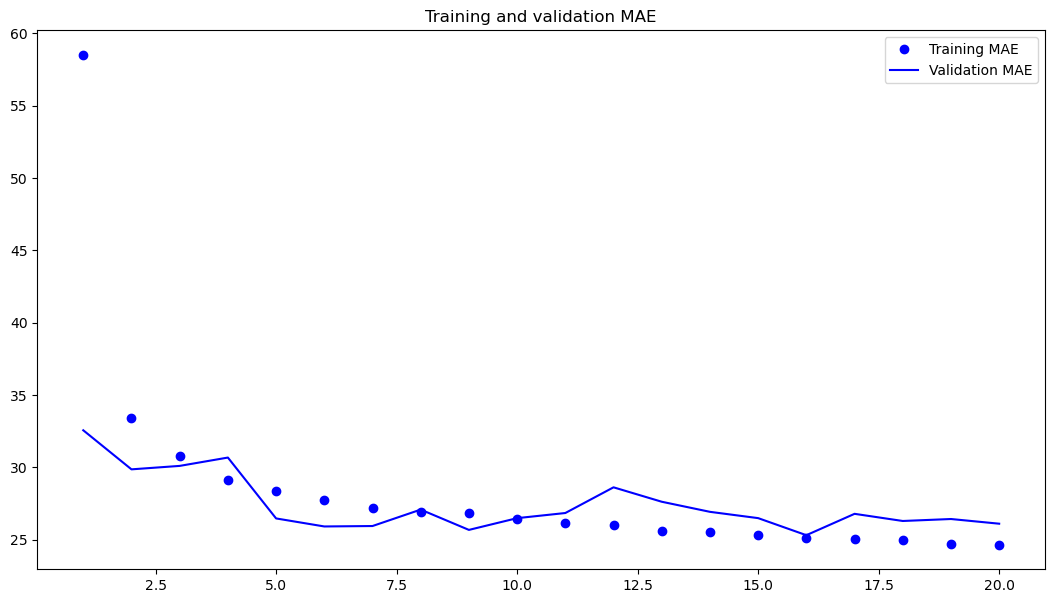

In [1179]:
def plot_training_performance(input):

    training_loss, training_mae, val_loss, val_mae = input[0], input[1], input[2], input[3]
    epochs = range(1, len(training_loss) + 1)
    
    plt.figure(figsize=(13, 7))
    plt.plot(epochs, training_mae, "bo", label="Training MAE")
    plt.plot(epochs, val_mae, "b", label="Validation MAE")
    plt.title("Training and validation MAE")
    plt.legend()

plot_training_performance([[18353.6348, 1858.9884, 1607.7172, 1457.3761, 1385.5718, 1338.3108, 1287.6559, 1278.9958, 1259.6697, 1225.3079, 1201.8513, 1190.3544, 1144.4662, 1148.0559, 1134.0468, 1115.6722, 1103.0052, 1108.9458, 1075.7786, 1078.186], [58.5147, 33.4168, 30.8022, 29.1382, 28.3788, 27.769, 27.2059, 26.9069, 26.8137, 26.4559, 26.1268, 25.9894, 25.6011, 25.5157, 25.3338, 25.1477, 25.0362, 24.9478, 24.6993, 24.6499], [1797.2273, 1525.7141, 1530.5348, 1566.4972, 1269.3385, 1218.5375, 1213.804, 1322.249, 1206.8118, 1277.0413, 1261.8284, 1446.4805, 1368.0836, 1309.2491, 1232.7797, 1170.7925, 1250.6863, 1259.7103, 1269.276, 1201.192], [32.563, 29.8631, 30.1015, 30.6775, 26.4709, 25.9159, 25.9458, 27.0813, 25.6783, 26.4902, 26.8448, 28.6207, 27.6244, 26.9267, 26.4916, 25.3125, 26.7889, 26.2941, 26.4305, 26.1065]])


In [113]:
G_9_4_2_loaded = keras.models.load_model("G_9_4_2.keras")
G_9_4_2_loaded.evaluate(G_9_4_2_X_test, G_9_4_2_y_test)

2143/2143 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 1166.4734 - mae: 25.3410


[1173.168701171875, 25.348705291748047]

Test performance of the model:

In [194]:
def log_loss(model, X_test, y_test):
    return ((np.log2(y_test) - np.log2(model.predict(X_test).reshape((len(y_test) ))))**2).mean()
    
def predicted_m_height(model, X_test):
    prediction = model.predict(X_test).flatten()
    __ = np.where(prediction < 1)[0]
    for i in range(len(prediction)):
        if i in __:
            prediction[i] = 1
    return prediction

print(f"Log Loss: {log_loss(G_9_4_2_loaded, G_9_4_2_X_test, G_9_4_2_y_test)}")

print(f"Prediction: {predicted_m_height(G_9_4_2_loaded, G_9_4_2_X_test)}")

2143/2143 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step
Log Loss: 0.1268145875238566
2143/2143 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step
Prediction: [148.73944 148.52321 208.03038 ... 131.15588 152.52289 160.96054]


#### Case 2:     n = 9, k = 4, m = 3

In [197]:
G_9_4_3 = data[(data.n.isin([9])) & (data.k.isin([4])) & (data.m == 3)].reset_index().iloc[:,1:]

G_9_4_3

,n,k,m,result,P
0,9,4,3,565.010999,"[91.14110355866848, -15.260304068831033, -47.3..."
1,9,4,3,589.760179,"[64.74058098310996, 81.79511155782794, 91.6281..."
2,9,4,3,463.271998,"[-85.6316790763519, -26.000127303987483, 48.55..."
3,9,4,3,467.150656,"[-99.82259518094696, -11.96128297965781, 18.61..."
4,9,4,3,358.122508,"[40.283983444300276, -8.251931684948616, 19.85..."
...,...,...,...,...,...
458630,9,4,3,235.177986,"[2.6670093587718213, 55.658387911571594, 11.99..."
458631,9,4,3,274.113064,"[28.045652915232864, 29.585318944895334, -91.0..."
458632,9,4,3,234.412083,"[-48.45145564706144, 13.391734670400908, -64.0..."
458633,9,4,3,251.207120,"[32.96669175017408, -59.55356458971233, -74.43..."


In [199]:
G_9_4_3_X_train, G_9_4_3_y_train, G_9_4_3_X_val, G_9_4_3_y_val, G_9_4_3_X_test, G_9_4_3_y_test = convert_df_to_tf_input(G_9_4_3)

Dimensions of Input: (458635, 23)
Dimensions of Output: (458635,)


In [213]:
def model():
    model = keras.Sequential()
    model.add(layers.Dense(1024, activation = 'relu'))
    model.add(layers.Dense(1024, activation = 'relu'))
    model.add(layers.Dense(1024, activation = 'relu'))
    model.add(layers.Dense(1024, activation = 'relu'))
    model.add(layers.Dense(1024, activation = 'relu'))
    
    model.add(layers.Dense(1, activation = 'linear'))

    return model
G_9_4_3_model = model()
G_9_4_3_model.compile(optimizer = 'rmsprop',
                  loss = 'mse',
                  metrics = ['mae'])
    
G_9_4_3_callbacks = [
                    keras.callbacks.ModelCheckpoint("G_9_4_3.keras",
                                        save_best_only=True),
                    ]
G_9_4_3_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [217]:
G_9_4_3_model.fit(G_9_4_3_X_train,
                  G_9_4_3_y_train,
                  validation_data = (G_9_4_3_X_val, G_9_4_3_y_val),
                  callbacks=G_9_4_3_callbacks,
                  batch_size = 256,
                  epochs = 20)

Epoch 1/20
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 58s 46ms/step - loss: 25103.7930 - mae: 87.2298 - val_loss: 26683.6387 - val_mae: 99.9813
Epoch 2/20
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 57s 46ms/step - loss: 24332.1875 - mae: 85.1242 - val_loss: 26994.4922 - val_mae: 103.1637
Epoch 3/20
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 57s 46ms/step - loss: 23573.2051 - mae: 83.7937 - val_loss: 28170.8203 - val_mae: 110.4060
Epoch 4/20
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 57s 46ms/step - loss: 23064.8711 - mae: 83.1847 - val_loss: 27883.5000 - val_mae: 79.3227
Epoch 5/20
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 58s 47ms/step - loss: 24962.5293 - mae: 82.9651 - val_loss: 26622.7422 - val_mae: 76.5934
Epoch 6/20
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 59s 47ms/step - loss: 23762.4805 - mae: 82.6449 - val_loss: 27661.6758 - val_mae: 80.4983
Epoch 7/20
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 58s 47ms/step - loss: 23768.3477 - mae: 82.3493 - val_loss: 26006.5391 - val_mae: 76.5168
Epoch 8/20
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 59s 47ms/step - loss: 23245.0625

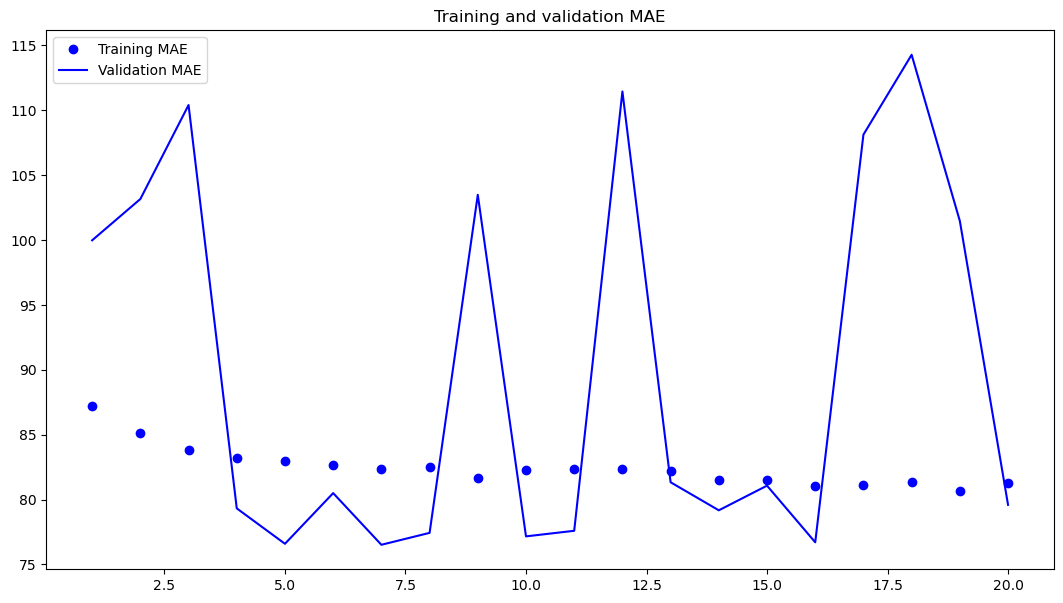

In [1181]:
plot_training_performance([[25103.793, 24332.1875, 23573.2051, 23064.8711, 24962.5293, 23762.4805, 23768.3477, 23245.0625, 22925.6367, 23789.4551, 24342.9238, 24730.0449, 23696.1172, 23283.5234, 22387.5527, 22164.4844, 22450.4941, 23334.2324, 22479.8301, 22597.0859], [87.2298, 85.1242, 83.7937, 83.1847, 82.9651, 82.6449, 82.3493, 82.5307, 81.6284, 82.2863, 82.3308, 82.3595, 82.1659, 81.4959, 81.5123, 81.009, 81.0889, 81.3567, 80.6937, 81.28], [26683.6387, 26994.4922, 28170.8203, 27883.5, 26622.7422, 27661.6758, 26006.5391, 25325.7969, 26794.8828, 26962.793, 26447.6484, 27832.8809, 24644.4746, 24736.0273, 24641.4082, 26745.4512, 27223.457, 28837.8164, 26245.8184, 25326.6719], [99.9813, 103.1637, 110.406, 79.3227, 76.5934, 80.4983, 76.5168, 77.4348, 103.4848, 77.1645, 77.5951, 111.4515, 81.3343, 79.1734, 81.0731, 76.7081, 108.1259, 114.2798, 101.4678, 79.5936]])


In [219]:
G_9_4_3_loaded = keras.models.load_model("G_9_4_3.keras")
G_9_4_3_loaded.evaluate(G_9_4_3_X_test, G_9_4_3_y_test)

2150/2150 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 27056.1152 - mae: 80.8635


[24907.80078125, 80.5205078125]

Test Performance of the model:

In [220]:
print(f"Log Loss: {log_loss(G_9_4_3_loaded, G_9_4_3_X_test, G_9_4_3_y_test)}")

print(f"Prediction: {predicted_m_height(G_9_4_3_loaded, G_9_4_3_X_test)}")

2150/2150 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step
Log Loss: 0.23605276755883706
2150/2150 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step
Prediction: [298.9101  286.51685 260.85327 ... 320.25656 290.1755  272.3992 ]


#### Case 3: n = 9, k = 4, m = 4

In [226]:
G_9_4_4 = data[(data.n.isin([9])) & (data.k.isin([4])) & (data.m == 4)].reset_index().iloc[:,1:]

G_9_4_4

,n,k,m,result,P
0,9,4,4,4185.626073,"[81.57553592587365, -71.2020592093956, -66.889..."
1,9,4,4,624.639051,"[-82.93968982955789, -82.53721578772151, -17.4..."
2,9,4,4,2573.811540,"[-85.49824195317275, -17.997627648469333, -28...."
3,9,4,4,499.582975,"[55.103428205992685, 25.46285302303413, 1.9181..."
4,9,4,4,1673.698926,"[94.75006467538296, -54.861456579236965, -60.2..."
...,...,...,...,...,...
456153,9,4,4,849.860297,"[-38.4705912717852, 47.184799812850656, 25.491..."
456154,9,4,4,436.094011,"[44.94156455905224, -83.60626552457582, 67.360..."
456155,9,4,4,867.792985,"[9.02269787730961, -12.391022904325794, 83.694..."
456156,9,4,4,1612.152599,"[-77.55141933519388, 27.09220670339731, -50.35..."


In [240]:
G_9_4_4_model = model()
G_9_4_4_model.compile(optimizer = 'rmsprop',
                  loss = 'mse',
                  metrics = ['mae'])
    
G_9_4_4_callbacks = [
                    keras.callbacks.ModelCheckpoint("G_9_4_4.keras",
                                        save_best_only=True),
                    ]
G_9_4_4_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [246]:
G_9_4_4_model.fit(G_9_4_4_X_train,
                  G_9_4_4_y_train,
                  validation_data = (G_9_4_4_X_val, G_9_4_4_y_val),
                  callbacks=G_9_4_4_callbacks,
                  batch_size = 256,
                  epochs = 20)

Epoch 1/20
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 57s 46ms/step - loss: 5227174.0000 - mae: 805.3116 - val_loss: 3611583.0000 - val_mae: 888.1630
Epoch 2/20
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 58s 46ms/step - loss: 5625421.0000 - mae: 793.9799 - val_loss: 3581540.0000 - val_mae: 778.4841
Epoch 3/20
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 58s 46ms/step - loss: 4641533.5000 - mae: 800.2751 - val_loss: 3577081.2500 - val_mae: 762.5894
Epoch 4/20
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 58s 46ms/step - loss: 5429423.5000 - mae: 801.3033 - val_loss: 3581376.0000 - val_mae: 767.2733
Epoch 5/20
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 58s 46ms/step - loss: 4251771.5000 - mae: 790.3658 - val_loss: 3583373.5000 - val_mae: 771.8629
Epoch 6/20
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 57s 46ms/step - loss: 7189869.5000 - mae: 809.7650 - val_loss: 3577161.0000 - val_mae: 788.0799
Epoch 7/20
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 58s 47ms/step - loss: 4957901.0000 - mae: 804.7726 - val_loss: 3581319.2500 - val_mae: 821.4113
Epoch 8/20
1248/1248 ━━━━━━━━━━━━━

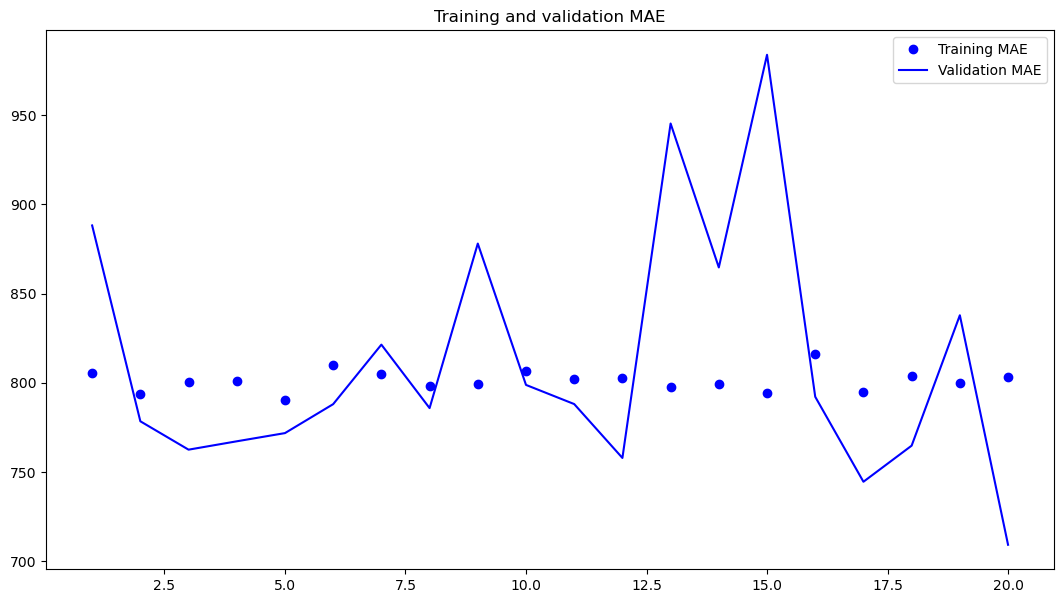

In [1183]:
plot_training_performance([[5227174.0, 5625421.0, 4641533.5, 5429423.5, 4251771.5, 7189869.5, 4957901.0, 5390824.0, 4896566.5, 5713499.0, 5558904.5, 5069529.0, 5106631.0, 5282923.0, 5252543.0, 6727058.5, 4934691.5, 5470251.5, 5066670.5, 5270823.0], [805.3116, 793.9799, 800.2751, 801.3033, 790.3658, 809.765, 804.7726, 798.3165, 799.4449, 806.6004, 802.3608, 802.8588, 797.9591, 799.418, 794.492, 816.362, 794.886, 803.7128, 800.1309, 803.4422], [3611583.0, 3581540.0, 3577081.25, 3581376.0, 3583373.5, 3577161.0, 3581319.25, 3579545.25, 3605619.0, 3579621.25, 3590752.0, 3603406.0, 3689131.0, 3600925.75, 3705163.0, 3570880.25, 3593281.75, 3622263.5, 3593155.5, 3641542.75], [888.163, 778.4841, 762.5894, 767.2733, 771.8629, 788.0799, 821.4113, 785.8629, 878.0105, 798.8549, 788.129, 757.9542, 945.2484, 864.6436, 983.745, 792.2056, 744.6218, 764.8373, 837.8536, 709.3203]])

In [248]:
G_9_4_4_loaded = keras.models.load_model("G_9_4_4.keras")
G_9_4_4_loaded.evaluate(G_9_4_4_X_test, G_9_4_4_y_test)

2139/2139 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 3692670.5000 - mae: 800.4199


[3795052.5, 795.058837890625]

In [250]:
print(f"Log Loss: {log_loss(G_9_4_4_loaded, G_9_4_4_X_test, G_9_4_4_y_test)}")

print(f"Prediction: {predicted_m_height(G_9_4_4_loaded, G_9_4_4_X_test)}")

2139/2139 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step
Log Loss: 1.074123473918071
2139/2139 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step
Prediction: [1414.4274 1365.617  1201.3776 ... 1476.0049 1080.5363 1313.7845]


#### Case 4: n = 9, k = 4, m = 5

In [256]:
G_9_4_5 = data[(data.n.isin([9])) & (data.k.isin([4])) & (data.m == 5)].reset_index().iloc[:,1:]

G_9_4_5

,n,k,m,result,P
0,9,4,5,30757.772723,"[52.11322076992937, 38.4959990023647, -39.8952..."
1,9,4,5,4604.376616,"[58.63791554744731, 2.5978474417976116, 50.890..."
2,9,4,5,6286.660357,"[-25.074155792987114, 97.34825824177395, 15.49..."
3,9,4,5,35424.142797,"[69.0514840527911, -6.325573540465967, 31.7300..."
4,9,4,5,278821.621548,"[49.468689374838476, 72.84861001129707, 31.660..."
...,...,...,...,...,...
458740,9,4,5,186083.799460,"[1.6760605702045694, -39.035333686385485, 2.83..."
458741,9,4,5,13011.678996,"[58.60842564781498, 32.327101391128565, 28.064..."
458742,9,4,5,35402.362115,"[0.43171584081433423, -40.172978518327355, 51...."
458743,9,4,5,145493.283933,"[-39.367901455852895, 33.054984117695, -50.528..."


In [258]:
G_9_4_5_X_train, G_9_4_5_y_train, G_9_4_5_X_val, G_9_4_5_y_val, G_9_4_5_X_test, G_9_4_5_y_test = convert_df_to_tf_input(G_9_4_5)

Dimensions of Input: (458745, 23)
Dimensions of Output: (458745,)


In [266]:
G_9_4_5_model = model()
G_9_4_5_model.compile(optimizer = 'rmsprop',
                  loss = 'mse',
                  metrics = ['mae'])
    
G_9_4_5_callbacks = [
                    keras.callbacks.ModelCheckpoint("G_9_4_5.keras",
                                        save_best_only=True),
                    ]
G_9_4_5_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [272]:
G_9_4_5_model.fit(G_9_4_5_X_train,
                  G_9_4_5_y_train,
                  validation_data = (G_9_4_5_X_val, G_9_4_5_y_val),
                  callbacks=G_9_4_5_callbacks,
                  batch_size = 256,
                  epochs = 20)

Epoch 1/20
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 58s 46ms/step - loss: 16471987060736.0000 - mae: 190979.9219 - val_loss: 2401881817088.0000 - val_mae: 154695.9062
Epoch 2/20
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 58s 46ms/step - loss: 27676626649088.0000 - mae: 195372.0938 - val_loss: 2402084978688.0000 - val_mae: 153905.8594
Epoch 3/20
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 58s 46ms/step - loss: 21132772114432.0000 - mae: 188124.2500 - val_loss: 2403340648448.0000 - val_mae: 148199.7188
Epoch 4/20
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 58s 46ms/step - loss: 35306556358656.0000 - mae: 189358.7188 - val_loss: 2403085582336.0000 - val_mae: 144249.8438
Epoch 5/20
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 58s 46ms/step - loss: 23488404389888.0000 - mae: 186830.3750 - val_loss: 2403215081472.0000 - val_mae: 150837.9844
Epoch 6/20
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 58s 46ms/step - loss: 53594871037952.0000 - mae: 218812.4062 - val_loss: 2402714386432.0000 - val_mae: 145416.1250
Epoch 7/20
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 57s 46ms/step - 

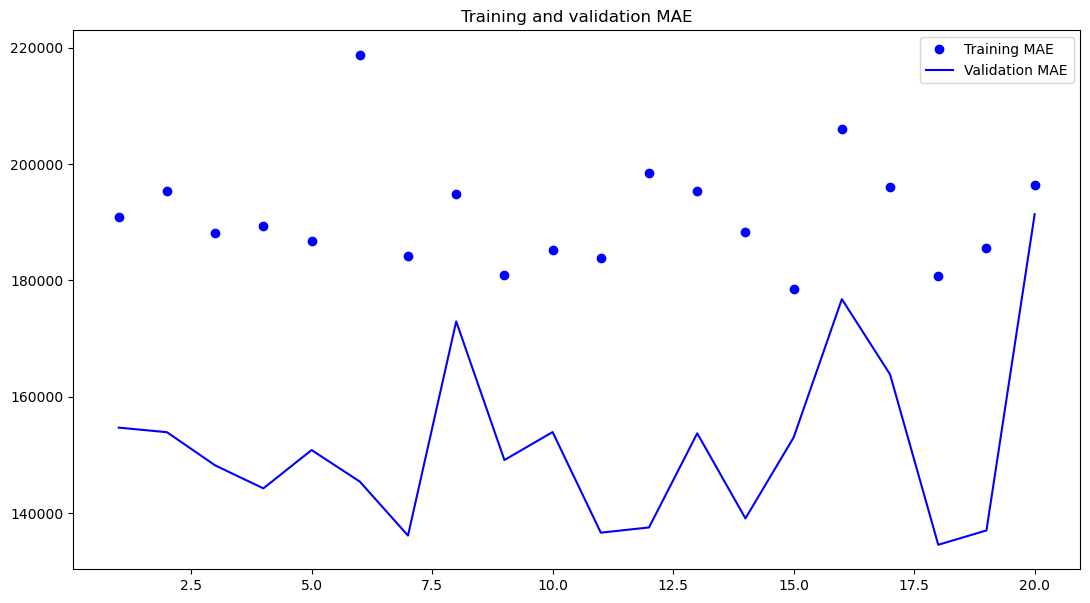

In [1185]:
plot_training_performance([[16471987060736.0, 27676626649088.0, 21132772114432.0, 35306556358656.0, 23488404389888.0, 53594871037952.0, 24063493799936.0, 25949076717568.0, 15642427129856.0, 16038543491072.0, 15790533246976.0, 33455612100608.0, 25964494979072.0, 25831583776768.0, 19473872453632.0, 53749368225792.0, 25850240040960.0, 17250556837888.0, 15135505645568.0, 28216737660928.0], [190979.9219, 195372.0938, 188124.25, 189358.7188, 186830.375, 218812.4062, 184267.4688, 194820.6719, 181018.7656, 185193.5, 183943.8125, 198413.3906, 195320.0938, 188363.5156, 178570.4844, 206098.6719, 196139.8438, 180693.9688, 185566.0156, 196369.9531], [2401881817088.0, 2402084978688.0, 2403340648448.0, 2403085582336.0, 2403215081472.0, 2402714386432.0, 2404805246976.0, 2402478194688.0, 2402941140992.0, 2404226695168.0, 2403702407168.0, 2403036823552.0, 2402293907456.0, 2403874635776.0, 2402474786816.0, 2403145613312.0, 2402737717248.0, 2403411951616.0, 2403277733888.0, 2403447078912.0], [154695.9062, 153905.8594, 148199.7188, 144249.8438, 150837.9844, 145416.125, 136130.4531, 172959.2969, 149124.4219, 153930.2344, 136628.5312, 137530.0, 153718.4688, 139083.2656, 153007.3438, 176795.125, 163847.1406, 134548.0312, 137017.6719, 191404.4531]])

In [274]:
G_9_4_5_loaded = keras.models.load_model("G_9_4_5.keras")
G_9_4_5_loaded.evaluate(G_9_4_5_X_test, G_9_4_5_y_test)

2151/2151 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 4362141433856.0000 - mae: 165201.1562


[4953838452736.0, 163129.265625]

Test performance of the model:

In [276]:
print(f"Log Loss: {log_loss(G_9_4_5_loaded, G_9_4_5_X_test, G_9_4_5_y_test)}")

print(f"Prediction: {predicted_m_height(G_9_4_5_loaded, G_9_4_5_X_test)}")

2151/2151 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step
Log Loss: 7.830406438158049
2151/2151 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step
Prediction: [ 87841.81 151181.55  83326.95 ... 113219.81 108320.23  89078.4 ]


#### Case 5: n = 9, k = 5, m = 2

In [281]:
G_9_5_2 = data[(data.n.isin([9])) & (data.k.isin([5])) & (data.m == 2)].reset_index().iloc[:,1:]

G_9_5_2

,n,k,m,result,P
0,9,5,2,304.080086,"[-96.7335333446977, -39.15276014752905, 67.920..."
1,9,5,2,225.708616,"[-28.102413320107004, -67.10882428430249, -13...."
2,9,5,2,256.018927,"[30.45861965849562, 66.14978381274531, -14.246..."
3,9,5,2,271.019593,"[-25.52374335314849, 58.783180766543154, 9.613..."
4,9,5,2,357.096560,"[19.45426237601953, 59.49663343758985, 81.4105..."
...,...,...,...,...,...
610593,9,5,2,220.575502,"[-68.24174123035169, 20.054796532536884, -39.1..."
610594,9,5,2,303.103972,"[89.87261011956474, -0.0874380532763297, -34.6..."
610595,9,5,2,462.435654,"[7.775515323034469, -50.763146084086195, 56.35..."
610596,9,5,2,1019.661163,"[18.434607954992785, 3.7278481392464755, 80.49..."


In [283]:
G_9_5_2_X_train, G_9_5_2_y_train, G_9_5_2_X_val, G_9_5_2_y_val, G_9_5_2_X_test, G_9_5_2_y_test = convert_df_to_tf_input(G_9_5_2)

Dimensions of Input: (610598, 23)
Dimensions of Output: (610598,)


In [291]:
G_9_5_2_model = model()
G_9_5_2_model.compile(optimizer = 'rmsprop',
                  loss = 'mse',
                  metrics = ['mae'])
    
G_9_5_2_callbacks = [
                    keras.callbacks.ModelCheckpoint("G_9_5_2.keras",
                                        save_best_only=True),
                    ]
G_9_5_2_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_36 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [297]:
G_9_5_2_model.fit(G_9_5_2_X_train,
                  G_9_5_2_y_train,
                  validation_data = (G_9_5_2_X_val, G_9_5_2_y_val),
                  callbacks=G_9_5_2_callbacks,
                  #batch_size = 256,
                  epochs = 20)

Epoch 1/20
13357/13357 ━━━━━━━━━━━━━━━━━━━━ 211s 16ms/step - loss: 27941.6250 - mae: 92.7075 - val_loss: 38949.5547 - val_mae: 140.7847
Epoch 2/20
13357/13357 ━━━━━━━━━━━━━━━━━━━━ 212s 16ms/step - loss: 27129.8398 - mae: 90.1811 - val_loss: 30197.2754 - val_mae: 85.0324
Epoch 3/20
13357/13357 ━━━━━━━━━━━━━━━━━━━━ 203s 15ms/step - loss: 26592.9473 - mae: 89.4075 - val_loss: 30013.5449 - val_mae: 93.2964
Epoch 4/20
13357/13357 ━━━━━━━━━━━━━━━━━━━━ 208s 16ms/step - loss: 27254.5977 - mae: 88.7075 - val_loss: 29700.2988 - val_mae: 91.0676
Epoch 5/20
13357/13357 ━━━━━━━━━━━━━━━━━━━━ 212s 16ms/step - loss: 26654.8105 - mae: 88.2905 - val_loss: 30190.0527 - val_mae: 83.7634
Epoch 6/20
13357/13357 ━━━━━━━━━━━━━━━━━━━━ 213s 16ms/step - loss: 26163.0098 - mae: 87.6686 - val_loss: 30198.9375 - val_mae: 99.1417
Epoch 7/20
13357/13357 ━━━━━━━━━━━━━━━━━━━━ 214s 16ms/step - loss: 26457.6465 - mae: 87.8233 - val_loss: 29481.5762 - val_mae: 89.5802
Epoch 8/20
13357/13357 ━━━━━━━━━━━━━━━━━━━━ 214s 16ms/

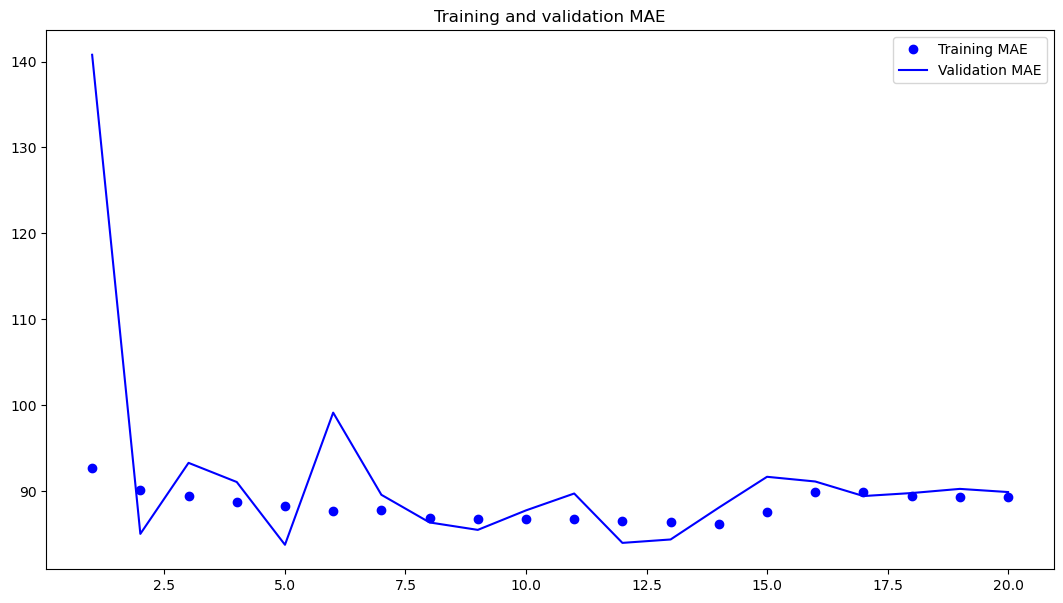

In [1189]:
plot_training_performance([[27941.625, 27129.8398, 26592.9473, 27254.5977, 26654.8105, 26163.0098, 26457.6465, 24965.418, 25333.7539, 26910.8574, 26431.8008, 26165.7363, 26101.0078, 25627.9746, 25569.3691, 27606.9922, 27832.709, 26388.4531, 25734.7148, 26438.7285], [92.7075, 90.1811, 89.4075, 88.7075, 88.2905, 87.6686, 87.8233, 86.8255, 86.7203, 86.8155, 86.725, 86.5117, 86.3676, 86.2251, 87.6273, 89.9341, 89.9496, 89.4824, 89.3784, 89.3029], [38949.5547, 30197.2754, 30013.5449, 29700.2988, 30190.0527, 30198.9375, 29481.5762, 29652.8125, 29815.9922, 29714.2188, 29476.873, 29777.7188, 29513.5977, 29439.6582, 30142.666, 30139.4785, 30175.248, 30160.5742, 30147.4922, 30156.9062], [140.7847, 85.0324, 93.2964, 91.0676, 83.7634, 99.1417, 89.5802, 86.3624, 85.4969, 87.7659, 89.7296, 83.9839, 84.381, 88.0864, 91.6747, 91.1281, 89.4344, 89.7832, 90.267, 89.8991]])

In [299]:
G_9_5_2_loaded = keras.models.load_model("G_9_5_2.keras")
G_9_5_2_loaded.evaluate(G_9_5_2_X_test, G_9_5_2_y_test)

2863/2863 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 28288.5625 - mae: 86.9143


[27759.794921875, 86.46817779541016]

Test performance of the model:

In [301]:
print(f"Log Loss: {log_loss(G_9_5_2_loaded, G_9_5_2_X_test, G_9_5_2_y_test)}")

print(f"Prediction: {predicted_m_height(G_9_5_2_loaded, G_9_5_2_X_test)}")

2863/2863 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step
Log Loss: 0.22084104099729765
2863/2863 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step
Prediction: [327.14865 405.87    336.71246 ... 320.94235 367.2611  271.86758]


#### Case 6: n = 9, k = 5, m = 3

In [303]:
G_9_5_3 = data[(data.n.isin([9])) & (data.k.isin([5])) & (data.m == 3)].reset_index().iloc[:,1:]

G_9_5_3

,n,k,m,result,P
0,9,5,3,392.259058,"[-90.74614563515692, 62.041803775298746, 73.98..."
1,9,5,3,667.392075,"[85.77005712638106, -45.72849369155219, -78.36..."
2,9,5,3,913.075625,"[-24.679589443635635, -7.543287624043202, 9.56..."
3,9,5,3,1592.451182,"[-29.075150970077473, 28.85469633492181, -91.4..."
4,9,5,3,551.708242,"[51.96069891828142, 53.25628013665923, -28.606..."
...,...,...,...,...,...
609795,9,5,3,404.342841,"[-32.93479407007101, 90.23991001776116, -96.29..."
609796,9,5,3,757.488748,"[-66.18054405404487, 50.76370432949773, 99.341..."
609797,9,5,3,669.114210,"[-44.91666887068452, 18.05446215340099, 26.877..."
609798,9,5,3,1190.738524,"[-72.46863559612021, 81.16349067682069, -51.98..."


In [305]:
G_9_5_3_X_train, G_9_5_3_y_train, G_9_5_3_X_val, G_9_5_3_y_val, G_9_5_3_X_test, G_9_5_3_y_test = convert_df_to_tf_input(G_9_5_3)

Dimensions of Input: (609800, 23)
Dimensions of Output: (609800,)


In [313]:
G_9_5_3_model = model()
G_9_5_3_model.compile(optimizer = 'rmsprop',
                  loss = 'mse',
                  metrics = ['mae'])
    
G_9_5_3_callbacks = [
                    keras.callbacks.ModelCheckpoint("G_9_5_3.keras",
                                        save_best_only=True),
                    ]
G_9_5_3_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_42 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [315]:
G_9_5_3_model.fit(G_9_5_3_X_train,
                  G_9_5_3_y_train,
                  validation_data = (G_9_5_3_X_val, G_9_5_3_y_val),
                  callbacks=G_9_5_3_callbacks,
                  batch_size = 128,
                  epochs = 20)

Epoch 1/20
3335/3335 ━━━━━━━━━━━━━━━━━━━━ 116s 34ms/step - loss: 8279428.5000 - mae: 937.3216 - val_loss: 5037636.0000 - val_mae: 930.2046
Epoch 2/20
3335/3335 ━━━━━━━━━━━━━━━━━━━━ 111s 33ms/step - loss: 7639940.5000 - mae: 908.9772 - val_loss: 5120994.5000 - val_mae: 1027.0676
Epoch 3/20
3335/3335 ━━━━━━━━━━━━━━━━━━━━ 112s 33ms/step - loss: 8835309.0000 - mae: 903.8517 - val_loss: 5026314.0000 - val_mae: 839.2909
Epoch 4/20
3335/3335 ━━━━━━━━━━━━━━━━━━━━ 112s 34ms/step - loss: 9418844.0000 - mae: 904.9226 - val_loss: 5022953.0000 - val_mae: 846.6761
Epoch 5/20
3335/3335 ━━━━━━━━━━━━━━━━━━━━ 112s 33ms/step - loss: 10038559.0000 - mae: 901.1804 - val_loss: 5031718.0000 - val_mae: 820.6158
Epoch 6/20
3335/3335 ━━━━━━━━━━━━━━━━━━━━ 113s 34ms/step - loss: 10846464.0000 - mae: 904.2725 - val_loss: 5030526.5000 - val_mae: 863.1566
Epoch 7/20
3335/3335 ━━━━━━━━━━━━━━━━━━━━ 113s 34ms/step - loss: 12842572.0000 - mae: 906.2368 - val_loss: 5032634.0000 - val_mae: 922.4465
Epoch 8/20
3335/3335 ━━

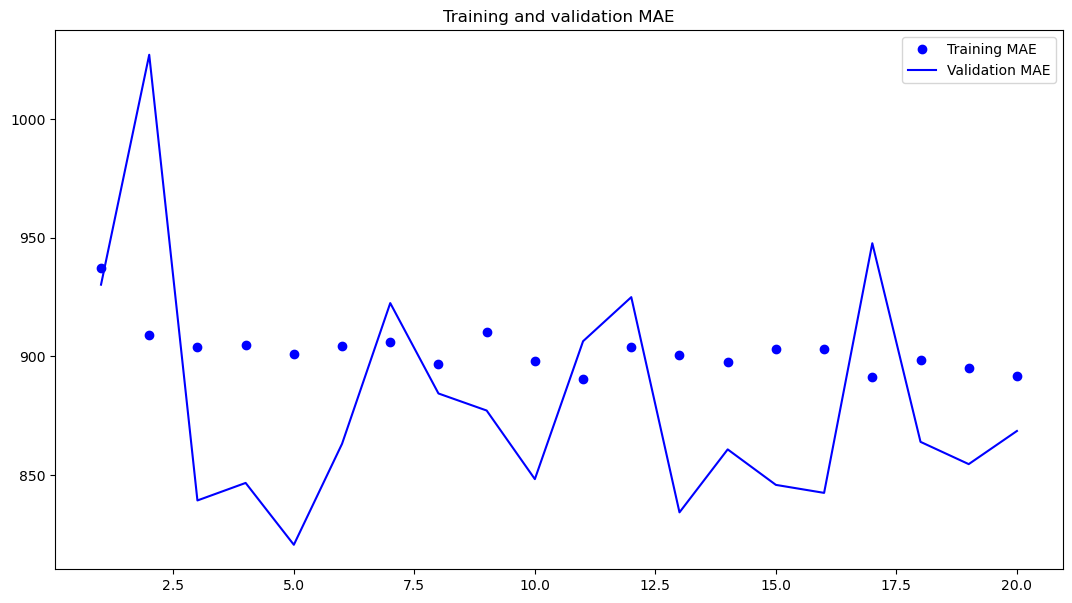

In [1195]:
plot_training_performance([[8279428.5, 7639940.5, 8835309.0, 9418844.0, 10038559.0, 10846464.0, 12842572.0, 6008909.0, 13519982.0, 7806548.5, 5761346.0, 7852655.0, 9239798.0, 10160106.0, 7986757.0, 7131660.0, 6477686.0, 7699649.0, 8971397.0, 6601339.5], [937.3216, 908.9772, 903.8517, 904.9226, 901.1804, 904.2725, 906.2368, 896.6894, 910.1844, 897.9224, 890.6039, 903.8083, 900.6017, 897.6187, 903.0497, 902.9073, 891.1141, 898.3589, 895.1003, 891.8228], [5037636.0, 5120994.5, 5026314.0, 5022953.0, 5031718.0, 5030526.5, 5032634.0, 5025979.5, 5040483.0, 5037312.0, 5025980.0, 5034006.5, 5044572.0, 5027192.5, 5024455.0, 5032123.0, 5052828.5, 5049590.5, 5033846.0, 5036083.5], [930.2046, 1027.0676, 839.2909, 846.6761, 820.6158, 863.1566, 922.4465, 884.3644, 877.1775, 848.28, 906.3828, 924.9553, 834.2789, 860.804, 845.8484, 842.4833, 947.6639, 863.9818, 854.5952, 868.5646]])

In [318]:
G_9_5_3_loaded = keras.models.load_model("G_9_5_3.keras")
G_9_5_3_loaded.evaluate(G_9_5_3_X_test, G_9_5_3_y_test)

2859/2859 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 9049144.0000 - mae: 882.3370


[10552415.0, 875.8076782226562]

Test performance of the model:

In [319]:
print(f"Log Loss: {log_loss(G_9_5_3_loaded, G_9_5_3_X_test, G_9_5_3_y_test)}")

print(f"Prediction: {predicted_m_height(G_9_5_3_loaded, G_9_5_3_X_test)}")

2859/2859 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step
Log Loss: 0.9965600581373991
2859/2859 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step
Prediction: [1477.1674 1326.2688 1357.4939 ... 1510.0634 1629.1132 1105.15  ]


#### Case 7: n = 9, k = 5, m = 4

In [323]:
G_9_5_4 = data[(data.n.isin([9])) & (data.k.isin([5])) & (data.m == 4)].reset_index().iloc[:,1:]

G_9_5_4

,n,k,m,result,P
0,9,5,4,19863.375738,"[64.2903089407022, -97.17442013202066, -59.379..."
1,9,5,4,14566.802705,"[-61.8565628325334, 26.642727507250868, 92.964..."
2,9,5,4,23596.569064,"[-13.129949845005058, 17.296063329187376, 40.2..."
3,9,5,4,6754.208993,"[-31.65163050919037, 67.44104799563956, 96.316..."
4,9,5,4,15305.881540,"[-40.34015314899687, -1.6922378076438775, -10...."
...,...,...,...,...,...
609705,9,5,4,9024.324825,"[-29.138518460683173, 84.46822691982604, -13.3..."
609706,9,5,4,31532.786759,"[96.96057671646125, 8.694226406443079, 28.9712..."
609707,9,5,4,7798.175920,"[-42.85443743031798, -82.69827664919276, -47.8..."
609708,9,5,4,10902.160747,"[55.639330551302834, -68.53615156432743, 42.58..."


In [325]:
G_9_5_4_X_train, G_9_5_4_y_train, G_9_5_4_X_val, G_9_5_4_y_val, G_9_5_4_X_test, G_9_5_4_y_test = convert_df_to_tf_input(G_9_5_4)

Dimensions of Input: (609710, 23)
Dimensions of Output: (609710,)


In [331]:
writing_test_dataset(G_9_5_4_X_test, G_9_5_4_y_test, 9, 5, 4)

In [333]:
G_9_5_4_model = model()
G_9_5_4_model.compile(optimizer = 'rmsprop',
                  loss = 'mse',
                  metrics = ['mae'])
    
G_9_5_4_callbacks = [
                    keras.callbacks.ModelCheckpoint("G_9_5_4.keras",
                                        save_best_only=True),
                    ]
G_9_5_4_model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_48 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [337]:
G_9_5_4_model.fit(G_9_5_4_X_train,
                  G_9_5_4_y_train,
                  validation_data = (G_9_5_4_X_val, G_9_5_4_y_val),
                  callbacks=G_9_5_4_callbacks,
                  batch_size = 256,
                  epochs = 20)

Epoch 1/20
1668/1668 ━━━━━━━━━━━━━━━━━━━━ 78s 47ms/step - loss: 51099281129472.0000 - mae: 250238.3906 - val_loss: 11517335437312.0000 - val_mae: 217549.6875
Epoch 2/20
1668/1668 ━━━━━━━━━━━━━━━━━━━━ 77s 46ms/step - loss: 34526753456128.0000 - mae: 249199.5938 - val_loss: 11519041470464.0000 - val_mae: 207593.1562
Epoch 3/20
1668/1668 ━━━━━━━━━━━━━━━━━━━━ 77s 46ms/step - loss: 42488739921920.0000 - mae: 247312.6250 - val_loss: 11516123283456.0000 - val_mae: 233072.9531
Epoch 4/20
1668/1668 ━━━━━━━━━━━━━━━━━━━━ 77s 46ms/step - loss: 36155886141440.0000 - mae: 248975.8750 - val_loss: 11519874039808.0000 - val_mae: 205859.0938
Epoch 5/20
1668/1668 ━━━━━━━━━━━━━━━━━━━━ 77s 46ms/step - loss: 28947171508224.0000 - mae: 248086.9062 - val_loss: 11515824439296.0000 - val_mae: 228251.9062
Epoch 6/20
1668/1668 ━━━━━━━━━━━━━━━━━━━━ 77s 46ms/step - loss: 18320327704576.0000 - mae: 228229.2812 - val_loss: 11518851678208.0000 - val_mae: 284634.9062
Epoch 7/20
1668/1668 ━━━━━━━━━━━━━━━━━━━━ 77s 46ms/s

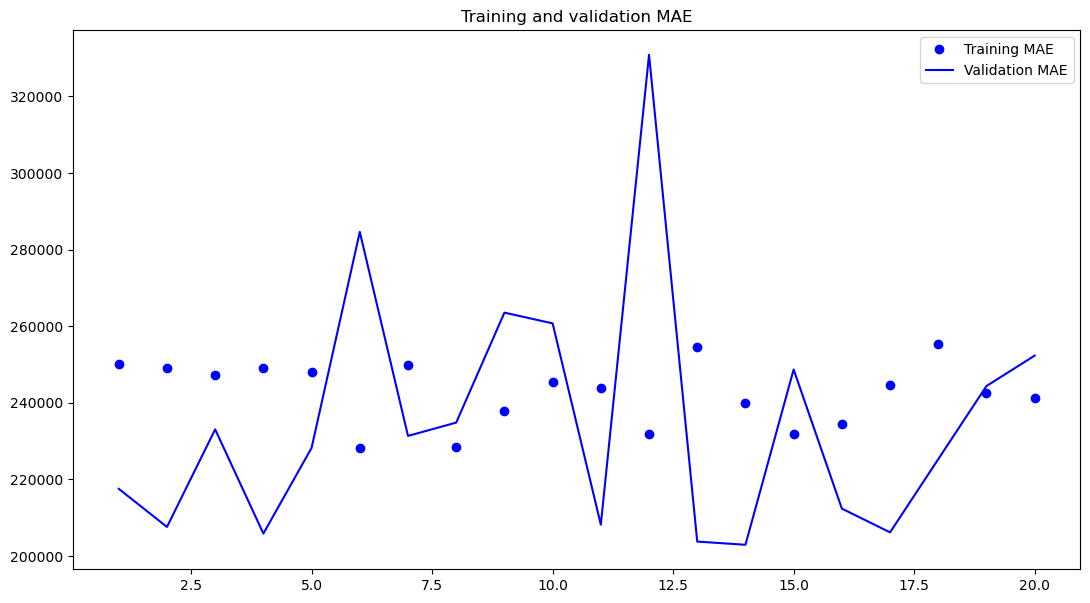

In [1199]:
plot_training_performance([[51099281129472.0, 34526753456128.0, 42488739921920.0, 36155886141440.0, 28947171508224.0, 18320327704576.0, 42006243966976.0, 17625316851712.0, 26332473851904.0, 22341948014592.0, 30133591212032.0, 22955278991360.0, 38269588865024.0, 29421218037760.0, 16330877042688.0, 23147308908544.0, 28951021879296.0, 57571457105920.0, 27062958030848.0, 17254279282688.0], [250238.3906, 249199.5938, 247312.625, 248975.875, 248086.9062, 228229.2812, 249756.0, 228373.0312, 237855.7344, 245423.7812, 243993.3906, 231861.0, 254605.4062, 240071.6406, 231752.0156, 234521.8438, 244665.6094, 255341.7344, 242454.5312, 241288.4219], [11517335437312.0, 11519041470464.0, 11516123283456.0, 11519874039808.0, 11515824439296.0, 11518851678208.0, 11516818489344.0, 11517047078912.0, 11515321122816.0, 11516545859584.0, 11519478726656.0, 11529134014464.0, 11517410934784.0, 11519000576000.0, 11517982408704.0, 11517251551232.0, 11518218338304.0, 11516220801024.0, 11515273936896.0, 11516254355456.0], [217549.6875, 207593.1562, 233072.9531, 205859.0938, 228251.9062, 284634.9062, 231363.1406, 234841.375, 263553.9062, 260755.4844, 208192.5156, 330888.5625, 203777.0, 202938.0156, 248708.6406, 212381.4531, 206179.5312, 225302.9688, 244388.5, 252335.4219]]
                         )

In [339]:
G_9_5_4_loaded = keras.models.load_model("G_9_5_4.keras")
G_9_5_4_loaded.evaluate(G_9_5_4_X_test, G_9_5_4_y_test)

2859/2859 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 44840691695616.0000 - mae: 263207.8438


[55830728671232.0, 277585.03125]

Test Performance of the model:

In [340]:
print(f"Log Loss: {log_loss(G_9_5_4_loaded, G_9_5_4_X_test, G_9_5_4_y_test)}")

print(f"Prediction: {predicted_m_height(G_9_5_4_loaded, G_9_5_4_X_test)}")

2859/2859 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step
Log Loss: 9.03517771608642
2859/2859 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step
Prediction: [158074.14 197255.77 152316.84 ... 206799.77 173998.42 128686.28]


#### Case 8: n = 9, k = 6, m = 2

In [358]:
G_9_6_2 = data[(data.n.isin([9])) & (data.k.isin([6])) & (data.m == 2)].reset_index().iloc[:,1:]

G_9_6_2

,n,k,m,result,P
0,9,6,2,1170.076493,"[92.83943954357875, -97.82331459868368, 5.3277..."
1,9,6,2,980.058846,"[-91.94318613457249, 38.21603950618828, -45.11..."
2,9,6,2,614.175508,"[-74.34849565522066, 25.338771057755793, -23.8..."
3,9,6,2,1924.132346,"[83.9246263907053, 37.190034790905884, -28.403..."
4,9,6,2,584.533743,"[-74.46873028902128, 65.09459936314249, 47.834..."
...,...,...,...,...,...
915113,9,6,2,705.213912,"[-12.474888286705678, 48.87643973177447, 92.76..."
915114,9,6,2,947.807365,"[57.03020043578755, 36.1430697274468, -63.0297..."
915115,9,6,2,1103.476089,"[-80.73206700521008, -7.570909428445134, 7.780..."
915116,9,6,2,419.528607,"[71.68307477852895, 84.15786113641005, 74.9043..."


In [360]:
G_9_6_2_X_train, G_9_6_2_y_train, G_9_6_2_X_val, G_9_6_2_y_val, G_9_6_2_X_test, G_9_6_2_y_test = convert_df_to_tf_input(G_9_6_2)

Dimensions of Input: (915118, 21)
Dimensions of Output: (915118,)


In [367]:
G_9_6_2_model = model()
G_9_6_2_model.compile(optimizer = 'rmsprop',
                  loss = 'mse',
                  metrics = ['mae'])
    
G_9_6_2_callbacks = [
                    keras.callbacks.ModelCheckpoint("G_9_6_2.keras",
                                        save_best_only=True),
                    ]
G_9_6_2_model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_54 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [370]:
G_9_6_2_model.fit(G_9_6_2_X_train,
                  G_9_6_2_y_train,
                  validation_data = (G_9_6_2_X_val, G_9_6_2_y_val),
                  callbacks=G_9_6_2_callbacks,
                  batch_size = 256,
                  epochs = 20)

Epoch 1/20
2503/2503 ━━━━━━━━━━━━━━━━━━━━ 120s 47ms/step - loss: 2321307.7500 - mae: 507.7035 - val_loss: 2619791.7500 - val_mae: 436.1562
Epoch 2/20
2503/2503 ━━━━━━━━━━━━━━━━━━━━ 116s 46ms/step - loss: 2402046.5000 - mae: 493.4890 - val_loss: 2588582.0000 - val_mae: 478.3466
Epoch 3/20
2503/2503 ━━━━━━━━━━━━━━━━━━━━ 116s 46ms/step - loss: 3401136.2500 - mae: 493.4955 - val_loss: 2587675.2500 - val_mae: 491.3807
Epoch 4/20
2503/2503 ━━━━━━━━━━━━━━━━━━━━ 115s 46ms/step - loss: 2336029.2500 - mae: 491.2048 - val_loss: 2589497.2500 - val_mae: 500.7313
Epoch 5/20
2503/2503 ━━━━━━━━━━━━━━━━━━━━ 116s 46ms/step - loss: 2230514.2500 - mae: 484.0947 - val_loss: 2608480.0000 - val_mae: 565.4755
Epoch 6/20
2503/2503 ━━━━━━━━━━━━━━━━━━━━ 116s 46ms/step - loss: 2270907.2500 - mae: 484.2462 - val_loss: 2628530.0000 - val_mae: 601.2800
Epoch 7/20
2503/2503 ━━━━━━━━━━━━━━━━━━━━ 116s 46ms/step - loss: 3402818.5000 - mae: 489.0249 - val_loss: 2586556.5000 - val_mae: 497.7763
Epoch 8/20
2503/2503 ━━━━━━

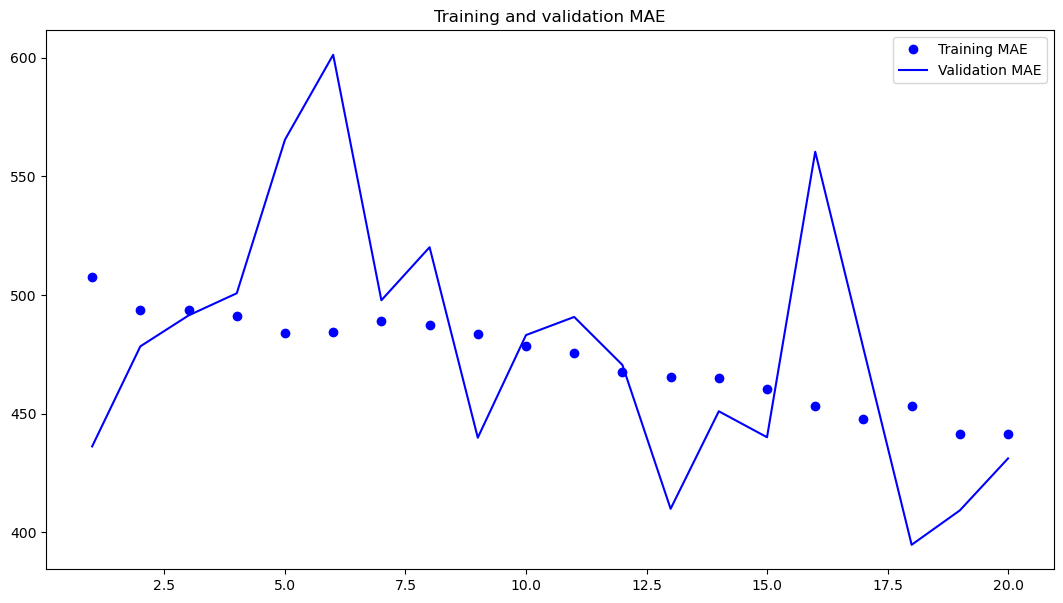

In [1203]:
plot_training_performance([[2321307.75, 2402046.5, 3401136.25, 2336029.25, 2230514.25, 2270907.25, 3402818.5, 2782491.5, 2683296.25, 2957647.25, 2359544.25, 2131287.5, 2995305.25, 2461343.5, 2577527.5, 2623726.0, 2363931.0, 2728365.25, 2441050.5, 2172893.25], [507.7035, 493.489, 493.4955, 491.2048, 484.0947, 484.2462, 489.0249, 487.1394, 483.7301, 478.6762, 475.7175, 467.5886, 465.5155, 464.8279, 460.2925, 453.0207, 447.8385, 453.264, 441.4404, 441.3515], [2619791.75, 2588582.0, 2587675.25, 2589497.25, 2608480.0, 2628530.0, 2586556.5, 2579849.0, 2570033.25, 2544771.75, 2560380.5, 2538137.5, 2549049.75, 2518841.0, 2517846.75, 2541372.25, 2507917.0, 2541800.75, 2495170.5, 2510812.75], [436.1562, 478.3466, 491.3807, 500.7313, 565.4755, 601.28, 497.7763, 520.1415, 439.834, 483.0998, 490.7437, 470.5121, 409.8508, 450.9758, 440.0325, 560.3954, 477.4406, 394.6868, 409.1854, 431.1004]]

                         )

In [390]:
G_9_6_2_loaded = keras.models.load_model("G_9_6_2.keras")
G_9_6_2_loaded.evaluate(G_9_6_2_X_test, G_9_6_2_y_test)

4290/4290 ━━━━━━━━━━━━━━━━━━━━ 39s 9ms/step - loss: 1776494.3750 - mae: 409.2357


[1570856.25, 404.7081604003906]

Test performance of the model:

In [391]:
print(f"Log Loss: {log_loss(G_9_6_2_loaded, G_9_6_2_X_test, G_9_6_2_y_test)}")

print(f"Prediction: {predicted_m_height(G_9_6_2_loaded, G_9_6_2_X_test)}")

4290/4290 ━━━━━━━━━━━━━━━━━━━━ 29s 7ms/step
Log Loss: 0.5543070050856967
4290/4290 ━━━━━━━━━━━━━━━━━━━━ 31s 7ms/step
Prediction: [1098.367  1625.7897 1263.3052 ...  854.4173  538.2667  658.4487]


#### Case 9: n = 9, k = 6, m = 3

In [392]:
G_9_6_3 = data[(data.n.isin([9])) & (data.k.isin([6])) & (data.m == 3)].reset_index().iloc[:,1:]

G_9_6_3

,n,k,m,result,P
0,9,6,3,20726.687921,"[36.76466888973516, -47.7424916770393, 91.3273..."
1,9,6,3,16373.452952,"[90.33840482367864, -50.28832508694984, -99.22..."
2,9,6,3,13088.839108,"[-82.28132026167475, 60.22660227469498, 54.759..."
3,9,6,3,16545.943681,"[-55.719764294548206, -46.407712419674674, 69...."
4,9,6,3,16341.609925,"[64.65536144986007, -12.145041318328865, -73.0..."
...,...,...,...,...,...
914574,9,6,3,67353.628145,"[63.62991104733172, -86.82414644521016, 43.230..."
914575,9,6,3,2555.680836,"[-60.002589671561566, -10.155454311416932, -16..."
914576,9,6,3,46667.823832,"[83.28061005753327, 92.92215584267646, 12.5923..."
914577,9,6,3,3679.188087,"[-55.43192057020572, -84.87278155156129, -94.6..."


In [393]:
G_9_6_3_X_train, G_9_6_3_y_train, G_9_6_3_X_val, G_9_6_3_y_val, G_9_6_3_X_test, G_9_6_3_y_test = convert_df_to_tf_input(G_9_6_3)

Dimensions of Input: (914579, 21)
Dimensions of Output: (914579,)


In [397]:
G_9_6_3_model = model()
G_9_6_3_model.compile(optimizer = 'rmsprop',
                  loss = 'mse',
                  metrics = ['mae'])
    
G_9_6_3_callbacks = [
                    keras.callbacks.ModelCheckpoint("G_9_6_3.keras",
                                        save_best_only=True),
                    ]
G_9_6_3_model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_60 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_63 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_65 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [398]:
G_9_6_3_model.fit(G_9_6_3_X_train,
                  G_9_6_3_y_train,
                  validation_data = (G_9_6_3_X_val, G_9_6_3_y_val),
                  callbacks=G_9_6_3_callbacks,
                  batch_size = 256,
                  epochs = 20)

Epoch 1/20
2501/2501 ━━━━━━━━━━━━━━━━━━━━ 119s 46ms/step - loss: 79206335643648.0000 - mae: 156138.5156 - val_loss: 47346859638784.0000 - val_mae: 158921.3750
Epoch 2/20
2501/2501 ━━━━━━━━━━━━━━━━━━━━ 115s 46ms/step - loss: 106136267128832.0000 - mae: 164529.9688 - val_loss: 47346389876736.0000 - val_mae: 148290.2812
Epoch 3/20
2501/2501 ━━━━━━━━━━━━━━━━━━━━ 115s 46ms/step - loss: 72300070174720.0000 - mae: 154930.5156 - val_loss: 47343244148736.0000 - val_mae: 162723.6406
Epoch 4/20
2501/2501 ━━━━━━━━━━━━━━━━━━━━ 115s 46ms/step - loss: 94541516374016.0000 - mae: 172268.4375 - val_loss: 47345089642496.0000 - val_mae: 153150.1406
Epoch 5/20
2501/2501 ━━━━━━━━━━━━━━━━━━━━ 115s 46ms/step - loss: 22276919525376.0000 - mae: 145085.4062 - val_loss: 47346138218496.0000 - val_mae: 166487.3438
Epoch 6/20
2501/2501 ━━━━━━━━━━━━━━━━━━━━ 118s 47ms/step - loss: 34848011976704.0000 - mae: 150668.5156 - val_loss: 47342136852480.0000 - val_mae: 177487.7188
Epoch 7/20
2501/2501 ━━━━━━━━━━━━━━━━━━━━ 118

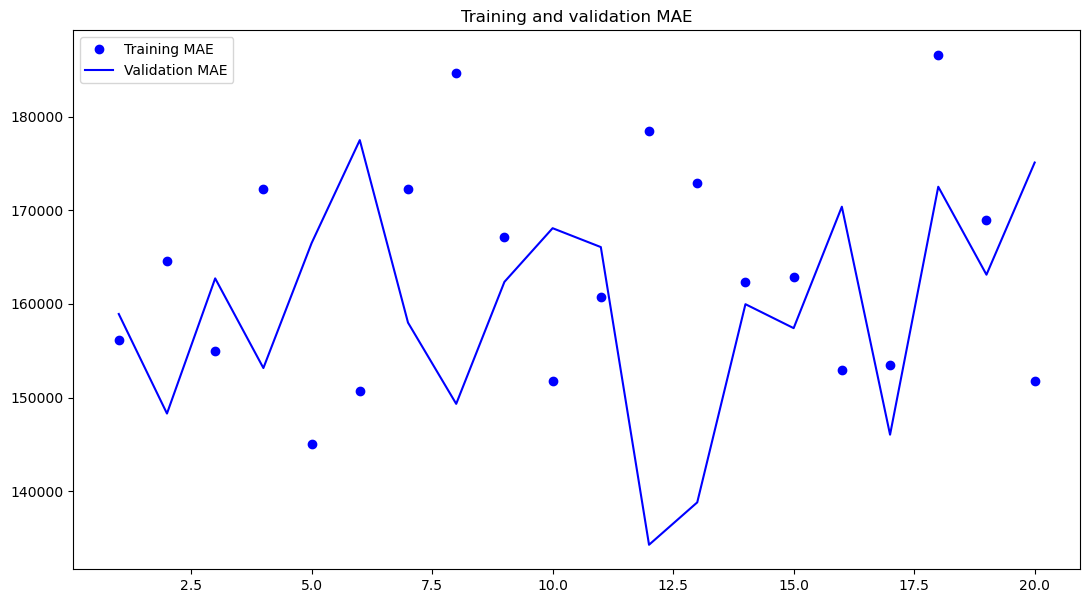

In [1206]:
plot_training_performance([[79206335643648.0, 106136267128832.0, 72300070174720.0, 94541516374016.0, 22276919525376.0, 34848011976704.0, 126554608762880.0, 153606552551424.0, 56514085650432.0, 49523225264128.0, 71121688854528.0, 132010123198464.0, 89906214862848.0, 59144581152768.0, 71313251106816.0, 35738313818112.0, 59971525935104.0, 171158540386304.0, 88070309281792.0, 38481455742976.0], [156138.5156, 164529.9688, 154930.5156, 172268.4375, 145085.4062, 150668.5156, 172254.1562, 184619.8594, 167099.3438, 151757.9062, 160780.1875, 178434.6875, 172945.9375, 162363.7656, 162852.6094, 152924.7031, 153450.7656, 186600.3906, 168989.9219, 151763.0156], [47346859638784.0, 47346389876736.0, 47343244148736.0, 47345089642496.0, 47346138218496.0, 47342136852480.0, 47343701327872.0, 47345303552000.0, 47345001562112.0, 47345215471616.0, 47345777508352.0, 47349002928128.0, 47347891437568.0, 47345114808320.0, 47345332912128.0, 47343403532288.0, 47346582814720.0, 47342942158848.0, 47345215471616.0, 47344821207040.0], [158921.375, 148290.2812, 162723.6406, 153150.1406, 166487.3438, 177487.7188, 157999.7031, 149325.2031, 162348.5781, 168081.75, 166066.5, 134276.9531, 138804.1719, 159967.8906, 157409.7344, 170375.8125, 146033.0938, 172507.7812, 163117.9531, 175093.4062]])

In [399]:
G_9_6_3_loaded = keras.models.load_model("G_9_6_3.keras")
G_9_6_3_loaded.evaluate(G_9_6_3_X_test, G_9_6_3_y_test)

4288/4288 ━━━━━━━━━━━━━━━━━━━━ 37s 9ms/step - loss: 21331263356928.0000 - mae: 160982.4375


[30606381547520.0, 174656.484375]

In [400]:
print(f"Log Loss: {log_loss(G_9_6_3_loaded, G_9_6_3_X_test, G_9_6_3_y_test)}")

print(f"Prediction: {predicted_m_height(G_9_6_3_loaded, G_9_6_3_X_test)}")

4288/4288 ━━━━━━━━━━━━━━━━━━━━ 34s 8ms/step
Log Loss: 9.606955459197705
4288/4288 ━━━━━━━━━━━━━━━━━━━━ 34s 8ms/step
Prediction: [126773.234  88973.69   91484.94  ... 120321.01   93996.21   73685.5  ]


#### Case 10: n = 10, k = 4, m = 2

In [427]:
G_10_4_2 = data[(data.n.isin([10])) & (data.k.isin([4])) & (data.m == 2)].reset_index().iloc[:,1:]

G_10_4_2

,n,k,m,result,P
0,10,4,2,132.255205,"[-90.44571704420741, -83.93146705280091, 49.53..."
1,10,4,2,67.208686,"[39.40559154826201, 31.446995925797637, -25.00..."
2,10,4,2,111.752611,"[-65.89946972446937, -29.07017047438775, 67.18..."
3,10,4,2,34.898275,"[-7.9423901460155975, -23.885950481192182, -33..."
4,10,4,2,25.015758,"[-83.47292061555156, -18.00670700483097, -81.6..."
...,...,...,...,...,...
364970,10,4,2,82.753409,"[-83.79789945204138, -29.987038936981975, 9.77..."
364971,10,4,2,92.928689,"[81.53956878915355, 64.61256768007686, -38.780..."
364972,10,4,2,80.558738,"[18.681608861618514, -78.17329246287622, 41.27..."
364973,10,4,2,21.318724,"[-10.968004542111643, 41.02432706836848, 88.88..."


In [428]:
G_10_4_2_X_train, G_10_4_2_y_train, G_10_4_2_X_val, G_10_4_2_y_val, G_10_4_2_X_test, G_10_4_2_y_test = convert_df_to_tf_input(G_10_4_2)

Dimensions of Input: (364975, 27)
Dimensions of Output: (364975,)


In [433]:
G_10_4_2_model = model()
G_10_4_2_model.compile(optimizer = 'rmsprop',
                  loss = 'mse',
                  metrics = ['mae'])
    
G_10_4_2_callbacks = [
                    keras.callbacks.ModelCheckpoint("G_10_4_2.keras",
                                        save_best_only=True),
                    ]
G_10_4_2_model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_66 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_67 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_68 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_69 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_70 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_71 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [434]:
G_10_4_2_model.fit(G_10_4_2_X_train,
                   G_10_4_2_y_train,
                   validation_data = (G_10_4_2_X_val, G_10_4_2_y_val),
                   callbacks=G_10_4_2_callbacks,
                   batch_size = 256,
                   epochs = 20)

Epoch 1/20
998/998 ━━━━━━━━━━━━━━━━━━━━ 49s 46ms/step - loss: 21277.7012 - mae: 48.1543 - val_loss: 1871.7269 - val_mae: 34.0866
Epoch 2/20
998/998 ━━━━━━━━━━━━━━━━━━━━ 46s 46ms/step - loss: 1893.0757 - mae: 35.0629 - val_loss: 1856.6144 - val_mae: 34.1025
Epoch 3/20
998/998 ━━━━━━━━━━━━━━━━━━━━ 46s 46ms/step - loss: 1873.4192 - mae: 34.9812 - val_loss: 1841.1993 - val_mae: 34.1375
Epoch 4/20
998/998 ━━━━━━━━━━━━━━━━━━━━ 46s 46ms/step - loss: 1843.4908 - mae: 34.7230 - val_loss: 1863.3695 - val_mae: 34.0087
Epoch 5/20
998/998 ━━━━━━━━━━━━━━━━━━━━ 47s 47ms/step - loss: 1846.3356 - mae: 34.8004 - val_loss: 1832.6293 - val_mae: 35.1907
Epoch 6/20
998/998 ━━━━━━━━━━━━━━━━━━━━ 46s 46ms/step - loss: 1838.4229 - mae: 34.7307 - val_loss: 1814.8302 - val_mae: 34.3790
Epoch 7/20
998/998 ━━━━━━━━━━━━━━━━━━━━ 46s 46ms/step - loss: 1832.9562 - mae: 34.6646 - val_loss: 1816.6821 - val_mae: 34.8271
Epoch 8/20
998/998 ━━━━━━━━━━━━━━━━━━━━ 46s 46ms/step - loss: 1820.5382 - mae: 34.5617 - val_loss: 1845

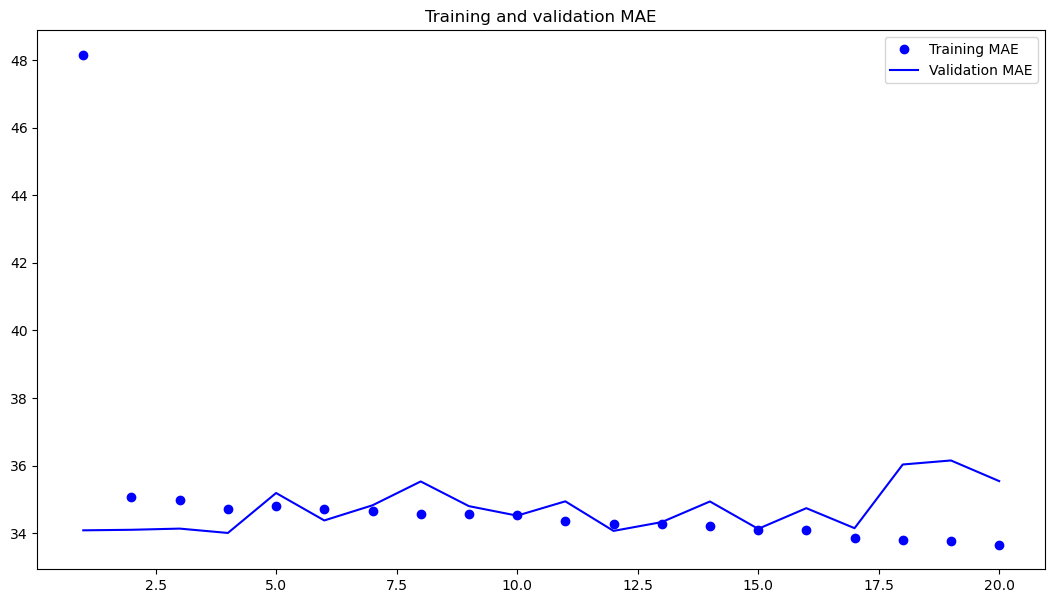

In [1210]:
plot_training_performance([[21277.7012, 1893.0757, 1873.4192, 1843.4908, 1846.3356, 1838.4229, 1832.9562, 1820.5382, 1820.4083, 1818.4188, 1802.5411, 1792.9816, 1795.2748, 1789.4722, 1773.5568, 1776.9343, 1753.817, 1746.6394, 1743.6267, 1736.8876], [48.1543, 35.0629, 34.9812, 34.723, 34.8004, 34.7307, 34.6646, 34.5617, 34.5668, 34.5434, 34.3654, 34.268, 34.2776, 34.2044, 34.0824, 34.1074, 33.8635, 33.8022, 33.7623, 33.659], [1871.7269, 1856.6144, 1841.1993, 1863.3695, 1832.6293, 1814.8302, 1816.6821, 1845.2114, 1817.4413, 1819.9005, 1818.5947, 1850.057, 1830.985, 1829.7009, 1960.7521, 1832.6559, 1858.228, 1888.8986, 1892.957, 1856.4731], [34.0866, 34.1025, 34.1375, 34.0087, 35.1907, 34.379, 34.8271, 35.5322, 34.8022, 34.5208, 34.9443, 34.0696, 34.3296, 34.94, 34.1302, 34.7416, 34.1499, 36.0341, 36.1531, 35.5427]]
)

In [435]:
G_10_4_2_loaded = keras.models.load_model("G_10_4_2.keras")
G_10_4_2_loaded.evaluate(G_10_4_2_X_test, G_10_4_2_y_test)

1711/1711 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 1847.0494 - mae: 34.6418


[1834.21875, 34.53688049316406]

Test Performance of the model

In [436]:
print(f"Log Loss: {log_loss(G_10_4_2_loaded, G_10_4_2_X_test, G_10_4_2_y_test)}")

print(f"Prediction: {predicted_m_height(G_10_4_2_loaded, G_10_4_2_X_test)}")

1711/1711 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step
Log Loss: 0.9105599246577946
1711/1711 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step
Prediction: [70.84871  62.84513  72.19157  ... 79.98891  61.489723 62.656345]


#### Case 11: n = 10, k = 4, m = 3

In [437]:
G_10_4_3 = data[(data.n.isin([10])) & (data.k.isin([4])) & (data.m == 3)].reset_index().iloc[:,1:]

G_10_4_3

,n,k,m,result,P
0,10,4,3,167.692765,"[-67.02930762978451, 82.95217006264068, -6.583..."
1,10,4,3,191.575292,"[9.306906289849366, 3.4333671985827863, 55.710..."
2,10,4,3,204.084917,"[-91.28427007108058, 13.766471261200735, 36.76..."
3,10,4,3,138.534876,"[-46.41573075931776, 60.941024847933164, 73.99..."
4,10,4,3,134.116417,"[49.22350855009063, 34.96193952283272, -39.398..."
...,...,...,...,...,...
366112,10,4,3,165.999643,"[98.33869444223794, 91.54650035628862, -23.300..."
366113,10,4,3,204.982586,"[-95.37057473412386, 0.08170124141750534, -72...."
366114,10,4,3,128.510490,"[95.65783919190304, 41.48635144712222, -5.5058..."
366115,10,4,3,120.176180,"[-27.010479648159333, 76.63770076556119, -66.3..."


In [438]:
G_10_4_3_X_train, G_10_4_3_y_train, G_10_4_3_X_val, G_10_4_3_y_val, G_10_4_3_X_test, G_10_4_3_y_test = convert_df_to_tf_input(G_10_4_3)

Dimensions of Input: (366117, 27)
Dimensions of Output: (366117,)


In [442]:
G_10_4_3_model = model()
G_10_4_3_model.compile(optimizer = 'rmsprop',
                  loss = 'mse',
                  metrics = ['mae'])
    
G_10_4_3_callbacks = [
                    keras.callbacks.ModelCheckpoint("G_10_4_3.keras",
                                        save_best_only=True),
                    ]
G_10_4_3_model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_72 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_73 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_74 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_75 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_76 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_77 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [443]:
G_10_4_3_model.fit(G_10_4_3_X_train,
                  G_10_4_3_y_train,
                  validation_data = (G_10_4_3_X_val, G_10_4_3_y_val),
                  callbacks=G_10_4_3_callbacks,
                  batch_size = 256,
                  epochs = 20)

Epoch 1/20
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 50s 47ms/step - loss: 27467.8457 - mae: 59.9866 - val_loss: 2624.4099 - val_mae: 38.3695
Epoch 2/20
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 45s 45ms/step - loss: 2019.9498 - mae: 31.9919 - val_loss: 1702.6123 - val_mae: 30.5898
Epoch 3/20
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 46s 46ms/step - loss: 1700.2544 - mae: 29.9535 - val_loss: 1984.9818 - val_mae: 31.8897
Epoch 4/20
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 46s 46ms/step - loss: 1586.1748 - mae: 28.9141 - val_loss: 1488.3550 - val_mae: 27.6870
Epoch 5/20
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 46s 46ms/step - loss: 1493.0118 - mae: 28.0112 - val_loss: 1483.9003 - val_mae: 26.7244
Epoch 6/20
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 46s 46ms/step - loss: 1494.5867 - mae: 27.6265 - val_loss: 1952.5266 - val_mae: 31.3964
Epoch 7/20
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 47s 47ms/step - loss: 1447.0240 - mae: 27.2058 - val_loss: 1417.1495 - val_mae: 26.5439
Epoch 8/20
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 46s 46ms/step - loss: 1414.1143 - mae: 26.8805 

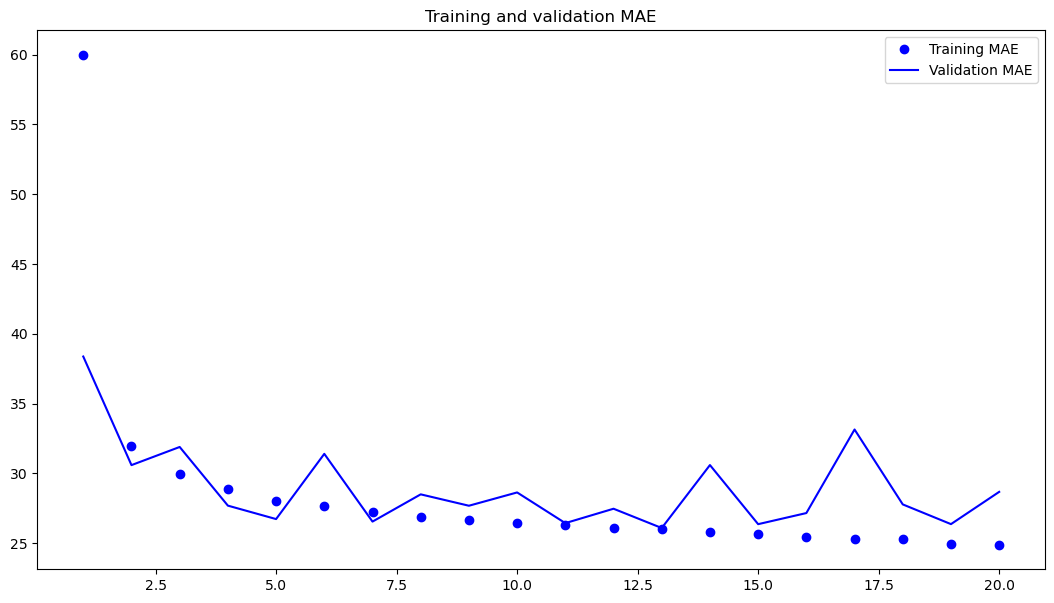

In [1213]:
plot_training_performance([[27467.8457, 2019.9498, 1700.2544, 1586.1748, 1493.0118, 1494.5867, 1447.024, 1414.1143, 1417.6129, 1407.2799, 1384.2168, 1340.4622, 1344.9861, 1372.1688, 1325.2549, 1269.9275, 1239.5208, 1292.0088, 1259.3033, 1245.5944], [59.9866, 31.9919, 29.9535, 28.9141, 28.0112, 27.6265, 27.2058, 26.8805, 26.6916, 26.4241, 26.318, 26.1021, 26.0073, 25.8115, 25.6456, 25.4236, 25.286, 25.311, 24.9737, 24.8827], [2624.4099, 1702.6123, 1984.9818, 1488.355, 1483.9003, 1952.5266, 1417.1495, 1503.9276, 1450.7253, 1499.361, 1462.1973, 1575.7911, 1382.5105, 1623.0074, 1459.0275, 1543.1123, 1807.6986, 1442.631, 1459.2415, 1490.9181], [38.3695, 30.5898, 31.8897, 27.687, 26.7244, 31.3964, 26.5439, 28.4955, 27.6796, 28.6321, 26.4339, 27.4653, 26.0833, 30.5934, 26.3593, 27.1551, 33.1413, 27.775, 26.3625, 28.6732]])

In [444]:
G_10_4_3_loaded = keras.models.load_model("G_10_4_3.keras")
G_10_4_3_loaded.evaluate(G_10_4_3_X_test, G_10_4_3_y_test)

1717/1717 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 1366.5410 - mae: 25.9073


[1387.4261474609375, 26.026174545288086]

Test performance of the model:

In [445]:
print(f"Log Loss: {log_loss(G_10_4_3_loaded, G_10_4_3_X_test, G_10_4_3_y_test)}")

print(f"Prediction: {predicted_m_height(G_10_4_3_loaded, G_10_4_3_X_test)}")

1717/1717 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step
Log Loss: 0.07691648547129626
1717/1717 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step
Prediction: [200.26909 183.45616 168.36244 ... 195.73369 153.8383  204.93768]


#### Case 12: n = 10, k = 4, m = 4

In [446]:
G_10_4_4 = data[(data.n.isin([10])) & (data.k.isin([4])) & (data.m == 4)].reset_index().iloc[:,1:]

G_10_4_4

,n,k,m,result,P
0,10,4,4,369.408485,"[-93.7609578156456, -37.861273606754686, 10.45..."
1,10,4,4,286.202660,"[-29.40666615921762, 15.374712552220643, 95.77..."
2,10,4,4,428.689224,"[-6.166468750779657, 64.3546887942037, 43.8590..."
3,10,4,4,298.037762,"[25.672775198057636, -7.0735886968491, -58.996..."
4,10,4,4,271.677267,"[-6.940897189241596, 68.72943373703495, 71.191..."
...,...,...,...,...,...
366816,10,4,4,289.955910,"[96.77870189699118, -45.586832066214726, 21.44..."
366817,10,4,4,349.682492,"[52.209642882357, -28.601070974222736, -22.806..."
366818,10,4,4,351.665858,"[-64.84502146971033, -77.25051853437743, 31.88..."
366819,10,4,4,217.050647,"[45.539650528297415, 86.34798045907672, 47.969..."


In [447]:
G_10_4_4_X_train, G_10_4_4_y_train, G_10_4_4_X_val, G_10_4_4_y_val, G_10_4_4_X_test, G_10_4_4_y_test = convert_df_to_tf_input(G_10_4_4)

Dimensions of Input: (366821, 27)
Dimensions of Output: (366821,)


In [451]:
G_10_4_4_model = model()
G_10_4_4_model.compile(optimizer = 'rmsprop',
                  loss = 'mse',
                  metrics = ['mae'])
    
G_10_4_4_callbacks = [
                    keras.callbacks.ModelCheckpoint("G_10_4_4.keras",
                                        save_best_only=True),
                    ]
G_10_4_4_model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_78 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_79 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_80 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_81 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_82 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_83 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [452]:
G_10_4_4_model.fit(G_10_4_4_X_train,
                  G_10_4_4_y_train,
                  validation_data = (G_10_4_4_X_val, G_10_4_4_y_val),
                  callbacks=G_10_4_4_callbacks,
                  batch_size = 256,
                  epochs = 20)

Epoch 1/20
1004/1004 ━━━━━━━━━━━━━━━━━━━━ 50s 47ms/step - loss: 92868.2969 - mae: 153.2480 - val_loss: 54747.8125 - val_mae: 130.2051
Epoch 2/20
1004/1004 ━━━━━━━━━━━━━━━━━━━━ 46s 46ms/step - loss: 52387.5625 - mae: 121.9519 - val_loss: 57106.8008 - val_mae: 147.1914
Epoch 3/20
1004/1004 ━━━━━━━━━━━━━━━━━━━━ 46s 46ms/step - loss: 51419.4414 - mae: 120.4536 - val_loss: 60739.6250 - val_mae: 163.5995
Epoch 4/20
1004/1004 ━━━━━━━━━━━━━━━━━━━━ 46s 46ms/step - loss: 51178.9727 - mae: 120.1099 - val_loss: 64235.1523 - val_mae: 176.3599
Epoch 5/20
1004/1004 ━━━━━━━━━━━━━━━━━━━━ 46s 46ms/step - loss: 47932.8945 - mae: 119.6397 - val_loss: 55815.5195 - val_mae: 138.7652
Epoch 6/20
1004/1004 ━━━━━━━━━━━━━━━━━━━━ 46s 46ms/step - loss: 48490.2891 - mae: 118.7908 - val_loss: 56776.2656 - val_mae: 112.1607
Epoch 7/20
1004/1004 ━━━━━━━━━━━━━━━━━━━━ 46s 46ms/step - loss: 47914.2734 - mae: 118.6753 - val_loss: 57487.1133 - val_mae: 150.4261
Epoch 8/20
1004/1004 ━━━━━━━━━━━━━━━━━━━━ 47s 46ms/step - loss

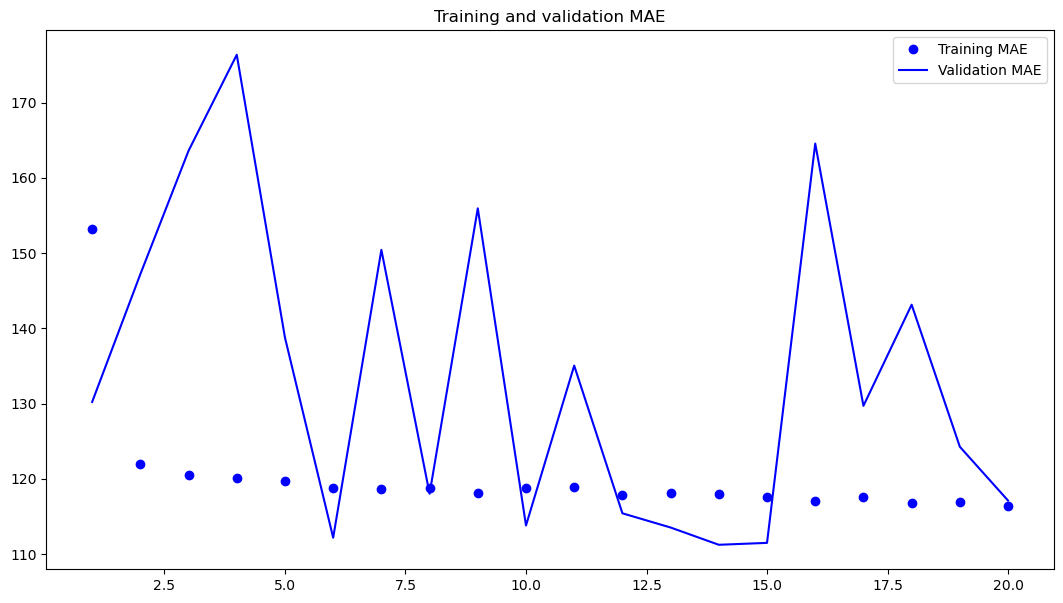

In [1216]:
plot_training_performance([[92868.2969, 52387.5625, 51419.4414, 51178.9727, 47932.8945, 48490.2891, 47914.2734, 47185.3711, 47763.1211, 52537.4883, 51609.8086, 46317.0781, 51022.8086, 50100.375, 49838.7891, 46896.2578, 46411.9609, 45233.3359, 47425.832, 45659.3672], [153.248, 121.9519, 120.4536, 120.1099, 119.6397, 118.7908, 118.6753, 118.8008, 118.1411, 118.7667, 118.8505, 117.8889, 118.164, 117.9516, 117.5843, 117.0599, 117.5661, 116.7983, 116.8788, 116.4251], [54747.8125, 57106.8008, 60739.625, 64235.1523, 55815.5195, 56776.2656, 57487.1133, 53616.918, 58675.0938, 56081.9961, 54363.3906, 58853.0977, 57242.3633, 54784.8477, 55590.4766, 60906.5703, 54095.4648, 55657.7031, 53214.1328, 54615.1758], [130.2051, 147.1914, 163.5995, 176.3599, 138.7652, 112.1607, 150.4261, 117.999, 155.9424, 113.7878, 135.0373, 115.4051, 113.5134, 111.22, 111.4744, 164.5568, 129.6856, 143.1365, 124.2482, 117.0957]])

In [453]:
G_10_4_4_loaded = keras.models.load_model("G_10_4_4.keras")
G_10_4_4_loaded.evaluate(G_10_4_4_X_test, G_10_4_4_y_test)

1720/1720 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 56894.4258 - mae: 124.5985


[57200.04296875, 124.9497299194336]

Test performance of the model:

In [454]:
print(f"Log Loss: {log_loss(G_10_4_4_loaded, G_10_4_4_X_test, G_10_4_4_y_test)}")

print(f"Prediction: {predicted_m_height(G_10_4_4_loaded, G_10_4_4_X_test)}")

1720/1720 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step
Log Loss: 0.32276229632135595
1720/1720 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step
Prediction: [389.61642 443.22818 315.83356 ... 383.9935  409.70648 399.37836]


#### Case 13: n = 10, k = 4, m = 5

In [455]:
G_10_4_5 = data[(data.n.isin([10])) & (data.k.isin([4])) & (data.m == 5)].reset_index().iloc[:,1:]

G_10_4_5

,n,k,m,result,P
0,10,4,5,424.649204,"[-68.38164320495247, 56.42791398151513, 11.328..."
1,10,4,5,1224.600561,"[81.29412365536913, 44.76502220130095, 98.5364..."
2,10,4,5,991.389171,"[72.38663982150996, 3.16026564965685, 66.07025..."
3,10,4,5,514.395208,"[-77.96185194234569, -13.007492911401926, 36.5..."
4,10,4,5,510.029988,"[-18.912648137354424, 41.741845557535015, -52...."
...,...,...,...,...,...
365868,10,4,5,707.325555,"[-96.3093840088104, 22.77669416403812, -68.377..."
365869,10,4,5,736.607865,"[-88.92164526152862, 95.63267075902411, -27.11..."
365870,10,4,5,1414.792112,"[-1.3555012110195008, -20.36385119736518, 19.1..."
365871,10,4,5,1075.703398,"[-62.97341065246197, 90.78872816685012, 95.112..."


In [456]:
G_10_4_5_X_train, G_10_4_5_y_train, G_10_4_5_X_val, G_10_4_5_y_val, G_10_4_5_X_test, G_10_4_5_y_test = convert_df_to_tf_input(G_10_4_5)

Dimensions of Input: (365873, 27)
Dimensions of Output: (365873,)


In [460]:
G_10_4_5_model = model()
G_10_4_5_model.compile(optimizer = 'rmsprop',
                  loss = 'mse',
                  metrics = ['mae'])
    
G_10_4_5_callbacks = [
                    keras.callbacks.ModelCheckpoint("G_10_4_5.keras",
                                        save_best_only=True),
                    ]
G_10_4_5_model.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_84 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_85 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_86 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_87 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_88 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_89 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [461]:
G_10_4_5_model.fit(G_10_4_5_X_train,
                  G_10_4_5_y_train,
                  validation_data = (G_10_4_5_X_val, G_10_4_5_y_val),
                  callbacks=G_10_4_5_callbacks,
                  batch_size = 256,
                  epochs = 20)

Epoch 1/20
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 50s 47ms/step - loss: 17096468.0000 - mae: 1230.2649 - val_loss: 12957172.0000 - val_mae: 1209.4480
Epoch 2/20
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 47s 46ms/step - loss: 14677231.0000 - mae: 1171.8954 - val_loss: 12955233.0000 - val_mae: 1217.6130
Epoch 3/20
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 46s 46ms/step - loss: 19193246.0000 - mae: 1187.0265 - val_loss: 13035763.0000 - val_mae: 1293.0613
Epoch 4/20
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 47s 46ms/step - loss: 13275977.0000 - mae: 1177.4369 - val_loss: 13043990.0000 - val_mae: 1316.9955
Epoch 5/20
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 46s 46ms/step - loss: 49063528.0000 - mae: 1210.6816 - val_loss: 12967506.0000 - val_mae: 1091.6787
Epoch 6/20
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 47s 47ms/step - loss: 11647849.0000 - mae: 1171.6241 - val_loss: 12948763.0000 - val_mae: 1220.2620
Epoch 7/20
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 46s 46ms/step - loss: 15193719.0000 - mae: 1184.5493 - val_loss: 12974545.0000 - val_mae: 1227.2865
Epoch 

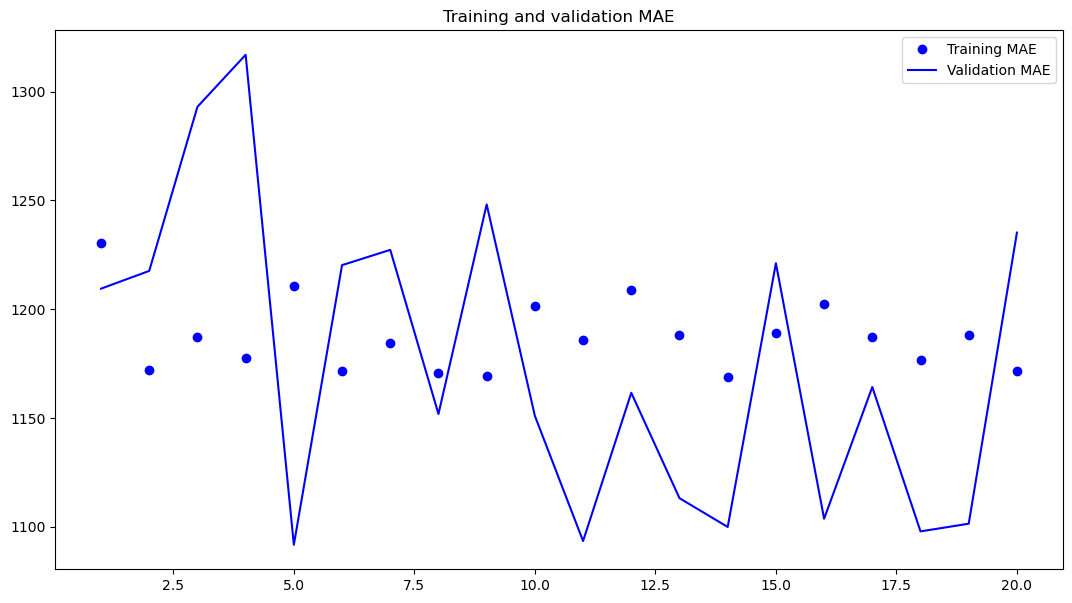

In [1220]:
plot_training_performance([[17096468.0, 14677231.0, 19193246.0, 13275977.0, 49063528.0, 11647849.0, 15193719.0, 9732464.0, 11530442.0, 33579476.0, 16497356.0, 21817736.0, 18688304.0, 12031349.0, 23677188.0, 18291788.0, 24271580.0, 10601172.0, 29072016.0, 14020085.0], [1230.2649, 1171.8954, 1187.0265, 1177.4369, 1210.6816, 1171.6241, 1184.5493, 1170.595, 1169.2278, 1201.6641, 1185.9086, 1208.7402, 1188.1589, 1168.7648, 1188.9846, 1202.4525, 1187.0419, 1176.4182, 1188.1476, 1171.4269], [12957172.0, 12955233.0, 13035763.0, 13043990.0, 12967506.0, 12948763.0, 12974545.0, 12963070.0, 12987198.0, 12934873.0, 12972384.0, 12939495.0, 12996962.0, 12963249.0, 13056336.0, 12950467.0, 12956993.0, 12979442.0, 12968857.0, 13077611.0], [1209.448, 1217.613, 1293.0613, 1316.9955, 1091.6787, 1220.262, 1227.2865, 1151.825, 1248.1747, 1150.9585, 1093.3993, 1161.5569, 1113.111, 1099.8663, 1221.1523, 1103.6487, 1164.2194, 1097.8324, 1101.3698, 1235.2112]])

In [462]:
G_10_4_5_loaded = keras.models.load_model("G_10_4_5.keras")
G_10_4_5_loaded.evaluate(G_10_4_5_X_test, G_10_4_5_y_test)

1716/1716 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 9847626.0000 - mae: 1174.5396


[10126270.0, 1175.1463623046875]

Test performance of the model

In [463]:
print(f"Log Loss: {log_loss(G_10_4_5_loaded, G_10_4_5_X_test, G_10_4_5_y_test)}")

print(f"Prediction: {predicted_m_height(G_10_4_5_loaded, G_10_4_5_X_test)}")

1716/1716 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step
Log Loss: 1.1237957583592826
1716/1716 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step
Prediction: [1801.4093 1664.0338 1841.277  ... 1595.1671 2089.0054 1799.4436]


#### Case 14: n = 10, k = 4, m = 6

In [464]:
G_10_4_6 = data[(data.n.isin([10])) & (data.k.isin([4])) & (data.m == 6)].reset_index().iloc[:,1:]

G_10_4_6

,n,k,m,result,P
0,10,4,6,42822.483197,"[32.263006124132716, 59.34168874668569, 89.932..."
1,10,4,6,70381.722359,"[-28.346971695960633, -50.082233387203395, -9...."
2,10,4,6,106802.555920,"[65.0945731374133, 38.98952586366377, 24.48209..."
3,10,4,6,29554.279110,"[-45.5486588867863, -54.01813670334538, -52.45..."
4,10,4,6,15288.924294,"[-11.607028211190965, 13.147302821011749, -26...."
...,...,...,...,...,...
364730,10,4,6,2347.112745,"[84.53083361376088, -16.427352005656275, 43.33..."
364731,10,4,6,37391.469405,"[-19.021264290246293, 51.09635471235276, 67.07..."
364732,10,4,6,99680.246057,"[-24.82667431662678, -73.05430522368076, -89.5..."
364733,10,4,6,19121.482732,"[-10.134129028348056, 65.51758636709687, -23.8..."


In [465]:
G_10_4_6_X_train, G_10_4_6_y_train, G_10_4_6_X_val, G_10_4_6_y_val, G_10_4_6_X_test, G_10_4_6_y_test = convert_df_to_tf_input(G_10_4_6)

Dimensions of Input: (364735, 27)
Dimensions of Output: (364735,)


In [468]:
writing_test_dataset(G_10_4_6_X_test, G_10_4_6_y_test, 10, 4, 6)

In [469]:
G_10_4_6_model = model()
G_10_4_6_model.compile(optimizer = 'rmsprop',
                  loss = 'mse',
                  metrics = ['mae'])
    
G_10_4_6_callbacks = [
                    keras.callbacks.ModelCheckpoint("G_10_4_6.keras",
                                        save_best_only=True),
                    ]
G_10_4_6_model.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_90 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_91 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_92 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_93 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_94 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_95 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [470]:
G_10_4_6_model.fit(G_10_4_6_X_train,
                  G_10_4_6_y_train,
                  validation_data = (G_10_4_6_X_val, G_10_4_6_y_val),
                  callbacks=G_10_4_6_callbacks,
                  batch_size = 256,
                  epochs = 20)

Epoch 1/20
998/998 ━━━━━━━━━━━━━━━━━━━━ 49s 47ms/step - loss: 27234928689152.0000 - mae: 307852.6250 - val_loss: 20395348459520.0000 - val_mae: 217784.6250
Epoch 2/20
998/998 ━━━━━━━━━━━━━━━━━━━━ 46s 46ms/step - loss: 33102372012032.0000 - mae: 317228.8125 - val_loss: 20386053881856.0000 - val_mae: 246294.8594
Epoch 3/20
998/998 ━━━━━━━━━━━━━━━━━━━━ 46s 46ms/step - loss: 23805456023552.0000 - mae: 296102.8125 - val_loss: 20389960876032.0000 - val_mae: 252849.8125
Epoch 4/20
998/998 ━━━━━━━━━━━━━━━━━━━━ 47s 47ms/step - loss: 34927921856512.0000 - mae: 327952.7500 - val_loss: 20386703998976.0000 - val_mae: 238797.7500
Epoch 5/20
998/998 ━━━━━━━━━━━━━━━━━━━━ 47s 47ms/step - loss: 36219257880576.0000 - mae: 327862.4062 - val_loss: 20388580950016.0000 - val_mae: 301295.8438
Epoch 6/20
998/998 ━━━━━━━━━━━━━━━━━━━━ 46s 46ms/step - loss: 42567177601024.0000 - mae: 337141.9375 - val_loss: 20391030423552.0000 - val_mae: 330741.9062
Epoch 7/20
998/998 ━━━━━━━━━━━━━━━━━━━━ 47s 47ms/step - loss: 65

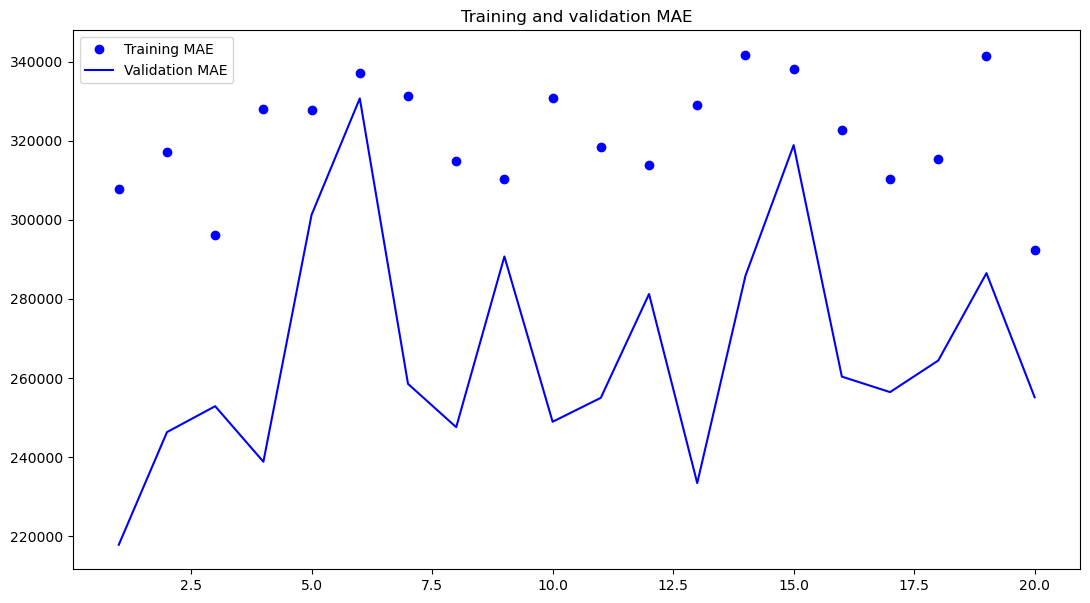

In [1224]:
plot_training_performance([[27234928689152.0, 33102372012032.0, 23805456023552.0, 34927921856512.0, 36219257880576.0, 42567177601024.0, 65146495959040.0, 41123582050304.0, 33952488226816.0, 42653475405824.0, 42147801726976.0, 34167827988480.0, 50884956389376.0, 64079364358144.0, 47353511804928.0, 37346653241344.0, 43458060353536.0, 59454162731008.0, 69540364943360.0, 26083971825664.0], [307852.625, 317228.8125, 296102.8125, 327952.75, 327862.4062, 337141.9375, 331392.9062, 314973.75, 310307.0, 330832.8125, 318480.9688, 313949.875, 329147.875, 341783.0938, 338279.1562, 322836.0312, 310370.6562, 315423.7188, 341408.7188, 292422.5938], [20395348459520.0, 20386053881856.0, 20389960876032.0, 20386703998976.0, 20388580950016.0, 20391030423552.0, 20385087094784.0, 20388199268352.0, 20384009158656.0, 20384181125120.0, 20394901766144.0, 20385860943872.0, 20388935368704.0, 20388329291776.0, 20389608554496.0, 20384095141888.0, 20383375818752.0, 20386160836608.0, 20392831877120.0, 20385462484992.0], [217784.625, 246294.8594, 252849.8125, 238797.75, 301295.8438, 330741.9062, 258509.9062, 247537.5156, 290744.0938, 248914.8594, 254976.375, 281245.25, 233394.1406, 285845.0938, 318915.3438, 260342.4062, 256419.4219, 264413.9375, 286525.9688, 255098.0938]]

                         )

In [471]:
G_10_4_6_loaded = keras.models.load_model("G_10_4_6.keras")
G_10_4_6_loaded.evaluate(G_10_4_6_X_test, G_10_4_6_y_test)

1710/1710 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 6827502731264.0000 - mae: 240797.4844


[21276387180544.0, 259097.609375]

Test Performance of the Model:

In [472]:
print(f"Log Loss: {log_loss(G_10_4_6_loaded, G_10_4_6_X_test, G_10_4_6_y_test)}")

print(f"Prediction: {predicted_m_height(G_10_4_6_loaded, G_10_4_6_X_test)}")

1710/1710 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step
Log Loss: 7.4608119112742415
1710/1710 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step
Prediction: [ 71271.98 103517.17 105136.31 ... 131170.88 158081.52 198079.81]


#### Case 15: n = 10, k = 5, m = 2

In [473]:
G_10_5_2 = data[(data.n.isin([10])) & (data.k.isin([5])) & (data.m == 2)].reset_index().iloc[:,1:]

G_10_5_2

,n,k,m,result,P
0,10,5,2,266.264524,"[-53.30165452517249, 46.36747377721454, 12.267..."
1,10,5,2,181.559741,"[-26.683305787405274, 64.80761728213591, -79.5..."
2,10,5,2,269.246769,"[90.83096572699475, -35.18352716178458, -83.01..."
3,10,5,2,218.660379,"[86.13486660391007, 1.0244745035444538, 74.863..."
4,10,5,2,176.134215,"[25.40895850201295, 3.255143376511498, 52.7008..."
...,...,...,...,...,...
458390,10,5,2,206.408403,"[-84.21772689698673, 72.9924006586896, -6.8424..."
458391,10,5,2,218.821840,"[-26.46729235828539, 31.056303680845645, -69.7..."
458392,10,5,2,192.196962,"[-29.093354195417888, 8.637528339948915, -28.3..."
458393,10,5,2,186.160579,"[-76.57310027236369, -56.32029429190193, 51.02..."


In [474]:
G_10_5_2_X_train, G_10_5_2_y_train, G_10_5_2_X_val, G_10_5_2_y_val, G_10_5_2_X_test, G_10_5_2_y_test = convert_df_to_tf_input(G_10_5_2)

Dimensions of Input: (458395, 28)
Dimensions of Output: (458395,)


In [478]:
G_10_5_2_model = model()
G_10_5_2_model.compile(optimizer = 'rmsprop',
                  loss = 'mse',
                  metrics = ['mae'])
    
G_10_5_2_callbacks = [
                    keras.callbacks.ModelCheckpoint("G_10_5_2.keras",
                                        save_best_only=True),
                    ]
G_10_5_2_model.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_96 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_97 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_98 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_99 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_100 (Dense)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_101 (Dense)               │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [479]:
G_10_5_2_model.fit(G_10_5_2_X_train,
                  G_10_5_2_y_train,
                  validation_data = (G_10_5_2_X_val, G_10_5_2_y_val),
                  callbacks=G_10_5_2_callbacks,
                  batch_size = 256,
                  epochs = 20)

Epoch 1/20
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 61s 46ms/step - loss: 18912.7402 - mae: 64.7439 - val_loss: 3714.6848 - val_mae: 41.8080
Epoch 2/20
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 58s 46ms/step - loss: 4009.4458 - mae: 43.2851 - val_loss: 3909.8503 - val_mae: 40.9240
Epoch 3/20
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 58s 46ms/step - loss: 3923.0251 - mae: 41.6879 - val_loss: 3361.8325 - val_mae: 38.7677
Epoch 4/20
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 58s 46ms/step - loss: 3608.2502 - mae: 40.0891 - val_loss: 3222.0154 - val_mae: 37.2851
Epoch 5/20
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 58s 46ms/step - loss: 3550.1436 - mae: 38.9267 - val_loss: 3175.1523 - val_mae: 36.5094
Epoch 6/20
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 58s 46ms/step - loss: 3335.5933 - mae: 38.0827 - val_loss: 3571.5378 - val_mae: 37.7605
Epoch 7/20
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 58s 46ms/step - loss: 3267.1917 - mae: 37.7037 - val_loss: 3660.3276 - val_mae: 38.2773
Epoch 8/20
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 58s 47ms/step - loss: 3356.8230 - mae: 37.2900 

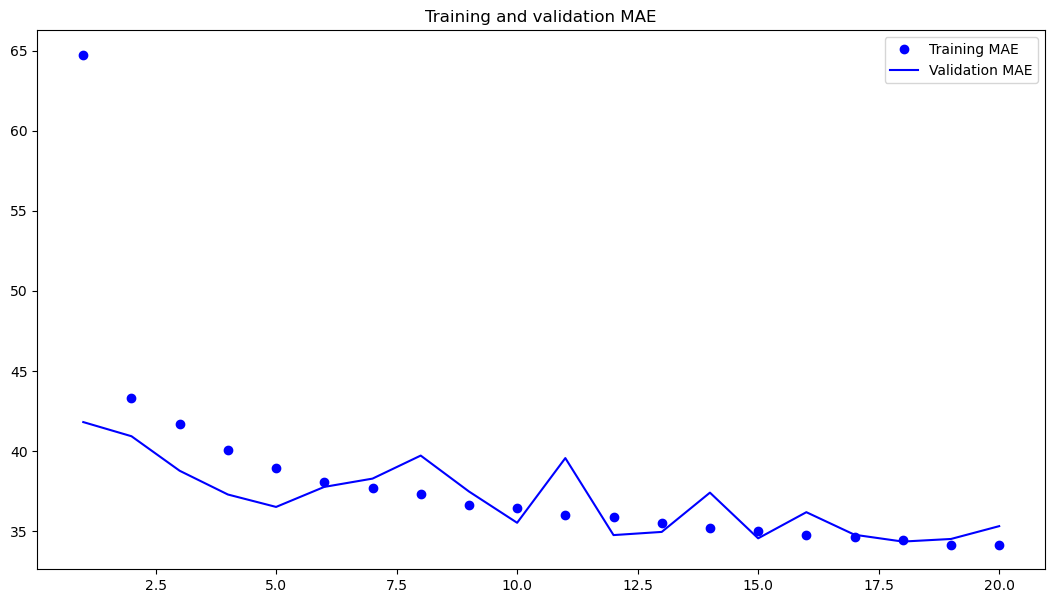

In [1228]:
plot_training_performance([[18912.7402, 4009.4458, 3923.0251, 3608.2502, 3550.1436, 3335.5933, 3267.1917, 3356.823, 3123.0681, 3211.9146, 2991.187, 3091.9849, 3016.3999, 2976.2148, 3063.5364, 2899.4597, 2959.6426, 2886.2478, 2765.512, 2866.9607], [64.7439, 43.2851, 41.6879, 40.0891, 38.9267, 38.0827, 37.7037, 37.29, 36.6585, 36.4513, 36.0138, 35.8821, 35.535, 35.1935, 35.0178, 34.7803, 34.6588, 34.4394, 34.146, 34.1579], [3714.6848, 3909.8503, 3361.8325, 3222.0154, 3175.1523, 3571.5378, 3660.3276, 3264.4502, 3096.9419, 3264.9324, 3219.113, 3077.603, 3175.7927, 3042.3865, 3105.8962, 3366.3657, 3162.3877, 2950.0161, 2954.9646, 3242.6914], [41.808, 40.924, 38.7677, 37.2851, 36.5094, 37.7605, 38.2773, 39.7158, 37.4755, 35.5198, 39.5594, 34.7509, 34.9493, 37.402, 34.549, 36.181, 34.7718, 34.3462, 34.5086, 35.3096]])

In [480]:
G_10_5_2_loaded = keras.models.load_model("G_10_5_2.keras")
G_10_5_2_loaded.evaluate(G_10_5_2_X_test, G_10_5_2_y_test)

2149/2149 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 2985.9780 - mae: 34.3179


[2997.08984375, 34.375736236572266]

Test Performance of the Model:

In [481]:
print(f"Log Loss: {log_loss(G_10_5_2_loaded, G_10_5_2_X_test, G_10_5_2_y_test)}")

print(f"Prediction: {predicted_m_height(G_10_5_2_loaded, G_10_5_2_X_test)}")

2149/2149 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step
Log Loss: 0.08371430992773672
2149/2149 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step
Prediction: [216.77231 171.93243 216.33896 ... 266.25726 207.70465 269.66037]


#### Case 16: n = 10, k = 5, m = 3

In [482]:
G_10_5_3 = data[(data.n.isin([10])) & (data.k.isin([5])) & (data.m == 3)].reset_index().iloc[:,1:]

G_10_5_3

,n,k,m,result,P
0,10,5,3,532.796392,"[-19.376058343322768, 97.54262374615203, 16.58..."
1,10,5,3,505.374405,"[-65.54760393867045, -97.9994752755463, -23.18..."
2,10,5,3,365.086018,"[-79.06749238151427, 19.7710693055174, 85.3282..."
3,10,5,3,524.673393,"[33.00397297948149, 19.398832218636144, -15.87..."
4,10,5,3,707.380328,"[35.819062417143186, 97.79675614827167, 63.417..."
...,...,...,...,...,...
459047,10,5,3,498.395509,"[49.27020353807907, 28.166611599489585, -40.83..."
459048,10,5,3,455.603668,"[-27.178046919189725, -49.32826001498761, 45.9..."
459049,10,5,3,443.835429,"[-23.299041526962256, -97.52760625432353, 86.3..."
459050,10,5,3,438.637123,"[81.87927032868359, -29.752983338567887, 32.56..."


In [483]:
G_10_5_3_X_train, G_10_5_3_y_train, G_10_5_3_X_val, G_10_5_3_y_val, G_10_5_3_X_test, G_10_5_3_y_test = convert_df_to_tf_input(G_10_5_3)

Dimensions of Input: (459052, 28)
Dimensions of Output: (459052,)


In [490]:
G_10_5_3_model = model()
G_10_5_3_model.compile(optimizer = 'rmsprop',
                  loss = 'mse',
                  metrics = ['mae'])
    
G_10_5_3_callbacks = [
                    keras.callbacks.ModelCheckpoint("G_10_5_3.keras",
                                        save_best_only=True),
                    ]
G_10_5_3_model.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_102 (Dense)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_103 (Dense)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_104 (Dense)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_105 (Dense)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_106 (Dense)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_107 (Dense)               │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [493]:
G_10_5_3_model.fit(G_10_5_3_X_train,
                  G_10_5_3_y_train,
                  validation_data = (G_10_5_3_X_val, G_10_5_3_y_val),
                  callbacks=G_10_5_3_callbacks,
                  batch_size = 256,
                  epochs = 20)

Epoch 1/20
1256/1256 ━━━━━━━━━━━━━━━━━━━━ 64s 48ms/step - loss: 127574.4453 - mae: 199.8230 - val_loss: 106897.9219 - val_mae: 160.0774
Epoch 2/20
1256/1256 ━━━━━━━━━━━━━━━━━━━━ 59s 47ms/step - loss: 99722.2031 - mae: 176.2075 - val_loss: 102781.6719 - val_mae: 187.3502
Epoch 3/20
1256/1256 ━━━━━━━━━━━━━━━━━━━━ 58s 46ms/step - loss: 100443.8828 - mae: 174.7822 - val_loss: 104815.4141 - val_mae: 159.1634
Epoch 4/20
1256/1256 ━━━━━━━━━━━━━━━━━━━━ 58s 46ms/step - loss: 104171.8906 - mae: 174.9613 - val_loss: 107420.4609 - val_mae: 208.1377
Epoch 5/20
1256/1256 ━━━━━━━━━━━━━━━━━━━━ 58s 46ms/step - loss: 103652.1562 - mae: 175.1885 - val_loss: 102808.0547 - val_mae: 189.9862
Epoch 6/20
1256/1256 ━━━━━━━━━━━━━━━━━━━━ 58s 46ms/step - loss: 102857.2656 - mae: 174.0039 - val_loss: 100944.3125 - val_mae: 167.5205
Epoch 7/20
1256/1256 ━━━━━━━━━━━━━━━━━━━━ 58s 46ms/step - loss: 100609.8359 - mae: 174.2563 - val_loss: 101281.6875 - val_mae: 176.1545
Epoch 8/20
1256/1256 ━━━━━━━━━━━━━━━━━━━━ 58s 46m

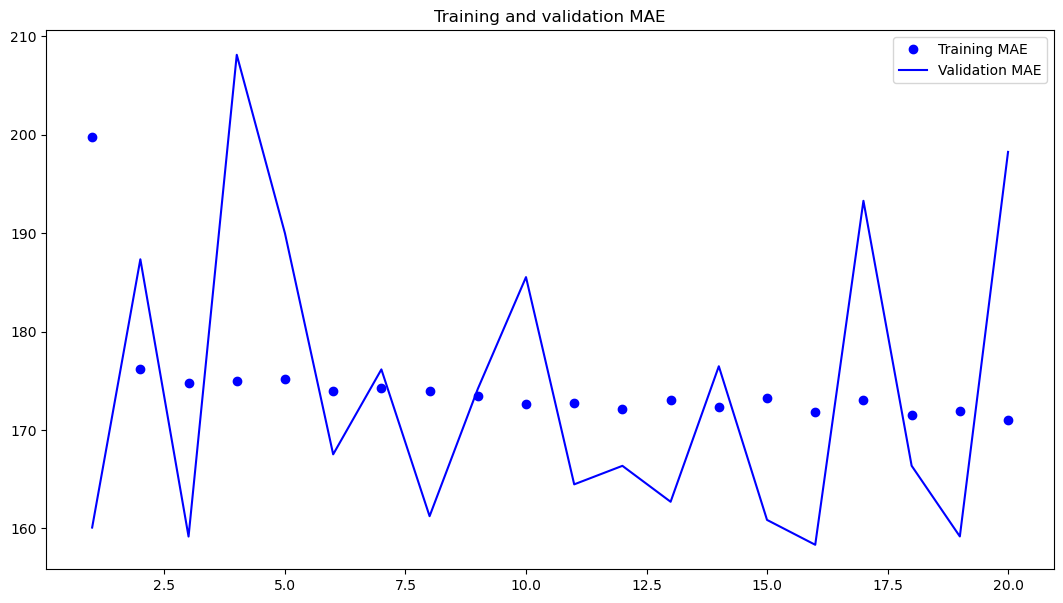

In [1234]:
plot_training_performance([[127574.4453, 99722.2031, 100443.8828, 104171.8906, 103652.1562, 102857.2656, 100609.8359, 99781.5625, 101560.4375, 100173.9531, 98128.9688, 96713.8906, 97789.8047, 98904.8281, 100572.75, 95778.9453, 100589.3438, 95702.4141, 99871.7031, 96312.0312], [199.823, 176.2075, 174.7822, 174.9613, 175.1885, 174.0039, 174.2563, 173.9671, 173.4523, 172.6254, 172.7834, 172.1165, 173.0163, 172.3036, 173.2599, 171.7909, 173.0869, 171.5648, 171.9596, 171.016], [106897.9219, 102781.6719, 104815.4141, 107420.4609, 102808.0547, 100944.3125, 101281.6875, 103128.375, 101026.3828, 101997.3594, 101344.1797, 101645.1641, 102752.7891, 101469.1016, 103921.2656, 104476.3516, 102913.4688, 100671.1328, 103897.2578, 104674.3281], [160.0774, 187.3502, 159.1634, 208.1377, 189.9862, 167.5205, 176.1545, 161.2331, 174.1683, 185.536, 164.4697, 166.3515, 162.6992, 176.4743, 160.8547, 158.327, 193.2924, 166.3593, 159.1748, 198.2659]]

                         )

In [494]:
G_10_5_3_loaded = keras.models.load_model("G_10_5_3.keras")
G_10_5_3_loaded.evaluate(G_10_5_3_X_test, G_10_5_3_y_test)

2152/2152 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 96375.1172 - mae: 165.9607


[102184.4765625, 167.50331115722656]

Test Performance of the Model:

In [495]:
print(f"Log Loss: {log_loss(G_10_5_3_loaded, G_10_5_3_X_test, G_10_5_3_y_test)}")

print(f"Prediction: {predicted_m_height(G_10_5_3_loaded, G_10_5_3_X_test)}")

2152/2152 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step
Log Loss: 0.34049194076723716
2152/2152 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step
Prediction: [441.8     503.12915 620.83203 ... 451.23923 507.08417 416.51187]


#### Case 17: n = 10, k = 5, m = 4

In [497]:
G_10_5_4 = data[(data.n.isin([10])) & (data.k.isin([5])) & (data.m == 4)].reset_index().iloc[:,1:]

G_10_5_4

,n,k,m,result,P
0,10,5,4,3073.245052,"[46.26416863933372, 50.34943535580106, 28.1052..."
1,10,5,4,991.518771,"[-16.13457642708103, -51.66081516473925, 6.639..."
2,10,5,4,2174.043610,"[-16.275556358392578, -1.491762949841032, 63.2..."
3,10,5,4,4585.980951,"[60.04947966813907, 92.88961191815898, -17.351..."
4,10,5,4,2738.274312,"[20.500305611392648, -32.092823557904055, -70...."
...,...,...,...,...,...
457279,10,5,4,1249.758282,"[-62.38353461942588, -38.601132739297306, 39.6..."
457280,10,5,4,1131.397811,"[-19.475686276021037, -66.80122605765838, -80...."
457281,10,5,4,4546.429793,"[86.60465399443251, 7.831080803217418, -75.384..."
457282,10,5,4,1349.072402,"[-32.90070127110921, 3.634785881851357, -67.07..."


In [498]:
G_10_5_4_X_train, G_10_5_4_y_train, G_10_5_4_X_val, G_10_5_4_y_val, G_10_5_4_X_test, G_10_5_4_y_test = convert_df_to_tf_input(G_10_5_4)

Dimensions of Input: (457284, 28)
Dimensions of Output: (457284,)


In [502]:
G_10_5_4_model = model()
G_10_5_4_model.compile(optimizer = 'rmsprop',
                  loss = 'mse',
                  metrics = ['mae'])
    
G_10_5_4_callbacks = [
                    keras.callbacks.ModelCheckpoint("G_10_5_4.keras",
                                        save_best_only=True),
                    ]
G_10_5_4_model.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_108 (Dense)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_109 (Dense)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_110 (Dense)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_111 (Dense)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_112 (Dense)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_113 (Dense)               │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [503]:
G_10_5_4_model.fit(G_10_5_4_X_train,
                  G_10_5_4_y_train,
                  validation_data = (G_10_5_4_X_val, G_10_5_4_y_val),
                  callbacks=G_10_5_4_callbacks,
                  batch_size = 256,
                  epochs = 20)

Epoch 1/20
1251/1251 ━━━━━━━━━━━━━━━━━━━━ 62s 48ms/step - loss: 24830594.0000 - mae: 1790.5082 - val_loss: 20001754.0000 - val_mae: 1497.2681
Epoch 2/20
1251/1251 ━━━━━━━━━━━━━━━━━━━━ 57s 46ms/step - loss: 35146012.0000 - mae: 1663.4193 - val_loss: 20697500.0000 - val_mae: 2141.3728
Epoch 3/20
1251/1251 ━━━━━━━━━━━━━━━━━━━━ 58s 46ms/step - loss: 49301792.0000 - mae: 1671.1110 - val_loss: 19920290.0000 - val_mae: 1729.3094
Epoch 4/20
1251/1251 ━━━━━━━━━━━━━━━━━━━━ 58s 46ms/step - loss: 31393016.0000 - mae: 1668.1746 - val_loss: 19876104.0000 - val_mae: 1586.8704
Epoch 5/20
1251/1251 ━━━━━━━━━━━━━━━━━━━━ 58s 46ms/step - loss: 20291122.0000 - mae: 1626.5592 - val_loss: 19873410.0000 - val_mae: 1568.3511
Epoch 6/20
1251/1251 ━━━━━━━━━━━━━━━━━━━━ 58s 46ms/step - loss: 44704676.0000 - mae: 1660.6790 - val_loss: 20170552.0000 - val_mae: 1473.5560
Epoch 7/20
1251/1251 ━━━━━━━━━━━━━━━━━━━━ 58s 47ms/step - loss: 19996970.0000 - mae: 1641.6787 - val_loss: 19969264.0000 - val_mae: 1518.4924
Epoch 

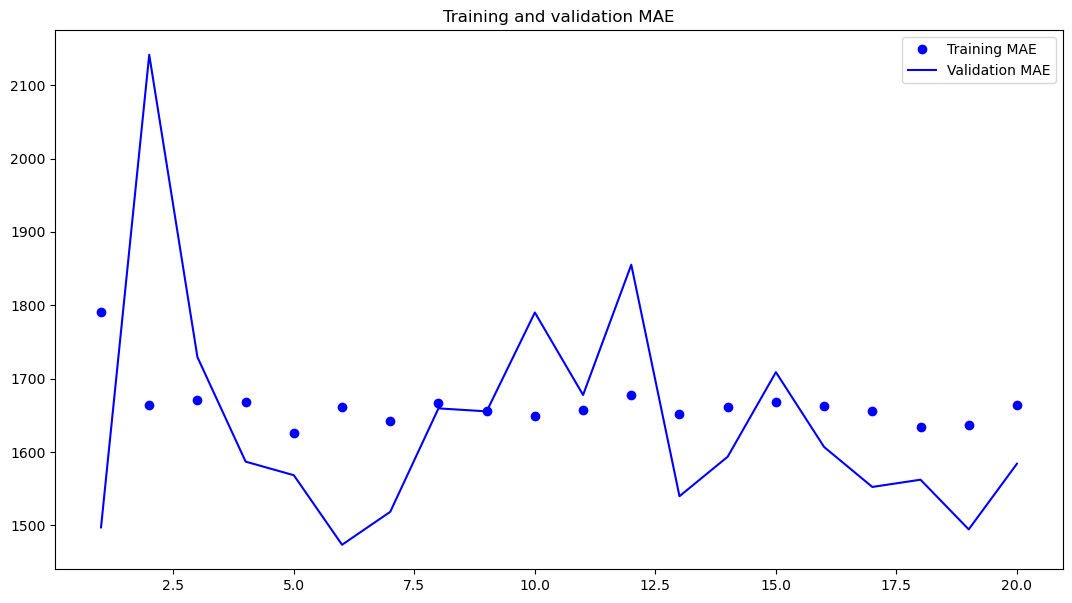

In [1238]:
plot_training_performance([[24830594.0, 35146012.0, 49301792.0, 31393016.0, 20291122.0, 44704676.0, 19996970.0, 37809016.0, 19634706.0, 19734946.0, 21164296.0, 33054206.0, 24905900.0, 29713470.0, 21320252.0, 29504058.0, 34312228.0, 20903402.0, 21074818.0, 34323328.0], [1790.5082, 1663.4193, 1671.111, 1668.1746, 1626.5592, 1660.679, 1641.6787, 1666.5499, 1655.9231, 1649.2283, 1656.5726, 1677.2704, 1651.6284, 1661.349, 1668.6516, 1662.8699, 1656.3826, 1633.948, 1637.1364, 1663.6763], [20001754.0, 20697500.0, 19920290.0, 19876104.0, 19873410.0, 20170552.0, 19969264.0, 19881116.0, 19891552.0, 20100324.0, 19971460.0, 20124486.0, 19952702.0, 19893322.0, 19909680.0, 19875636.0, 19896670.0, 19886390.0, 20065538.0, 19927612.0], [1497.2681, 2141.3728, 1729.3094, 1586.8704, 1568.3511, 1473.556, 1518.4924, 1659.4583, 1655.3821, 1790.1237, 1677.7347, 1855.2273, 1539.7537, 1593.5663, 1708.796, 1606.8146, 1552.3696, 1562.2526, 1494.5491, 1583.9751]]
                         )

In [504]:
G_10_5_4_loaded = keras.models.load_model("G_10_5_4.keras")
G_10_5_4_loaded.evaluate(G_10_5_4_X_test, G_10_5_4_y_test)

2144/2144 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 19874820.0000 - mae: 1572.5471


[20614618.0, 1571.1331787109375]

Test Performance of the Model:

In [505]:
print(f"Log Loss: {log_loss(G_10_5_4_loaded, G_10_5_4_X_test, G_10_5_4_y_test)}")

print(f"Prediction: {predicted_m_height(G_10_5_4_loaded, G_10_5_4_X_test)}")

2144/2144 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step
Log Loss: 1.0585868938320782
2144/2144 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step
Prediction: [2383.9197 2644.3494 2344.7268 ... 2656.497  2408.2202 2164.2107]


#### Case 18: n = 10, k = 5, m = 5

In [507]:
G_10_5_5 = data[(data.n.isin([10])) & (data.k.isin([5])) & (data.m == 5)].reset_index().iloc[:,1:]

G_10_5_5

,n,k,m,result,P
0,10,5,5,9640.146544,"[86.00944570924926, 77.20836314076664, -67.182..."
1,10,5,5,39133.045116,"[34.055361835806394, 53.145476822870705, 60.62..."
2,10,5,5,46822.050499,"[-41.25843291529673, 22.340752765756022, -19.0..."
3,10,5,5,16986.719702,"[30.053172640908002, -83.19823621301492, 63.03..."
4,10,5,5,66771.425616,"[-5.409583939761234, 61.325515007078224, 24.47..."
...,...,...,...,...,...
457878,10,5,5,20951.143575,"[-75.10121494421952, -48.96629663825818, 90.01..."
457879,10,5,5,36717.860797,"[-0.537190718626988, -71.25868272416685, 1.229..."
457880,10,5,5,80304.350109,"[16.219962173532878, 99.74533223873686, 78.899..."
457881,10,5,5,275766.337343,"[18.02239094026335, 98.39178570523077, -12.808..."


In [508]:
G_10_5_5_X_train, G_10_5_5_y_train, G_10_5_5_X_val, G_10_5_5_y_val, G_10_5_5_X_test, G_10_5_5_y_test = convert_df_to_tf_input(G_10_5_5)

Dimensions of Input: (457883, 28)
Dimensions of Output: (457883,)


In [512]:
G_10_5_5_model = model()
G_10_5_5_model.compile(optimizer = 'rmsprop',
                  loss = 'mse',
                  metrics = ['mae'])
    
G_10_5_5_callbacks = [
                    keras.callbacks.ModelCheckpoint("G_10_5_5.keras",
                                        save_best_only=True),
                    ]
G_10_5_5_model.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_114 (Dense)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_115 (Dense)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_116 (Dense)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_117 (Dense)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_118 (Dense)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_119 (Dense)               │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [513]:
G_10_5_5_model.fit(G_10_5_5_X_train,
                  G_10_5_5_y_train,
                  validation_data = (G_10_5_5_X_val, G_10_5_5_y_val),
                  callbacks=G_10_5_5_callbacks,
                  batch_size = 256,
                  epochs = 20)

Epoch 1/20
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 61s 46ms/step - loss: 144833377206272.0000 - mae: 568261.7500 - val_loss: 1530400597868544.0000 - val_mae: 666458.9375
Epoch 2/20
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 58s 46ms/step - loss: 72339395969024.0000 - mae: 529492.5625 - val_loss: 1530385028612096.0000 - val_mae: 693780.5000
Epoch 3/20
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 58s 46ms/step - loss: 111695246655488.0000 - mae: 543932.4375 - val_loss: 1530353084792832.0000 - val_mae: 730847.5625
Epoch 4/20
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 58s 46ms/step - loss: 137795167322112.0000 - mae: 557956.6875 - val_loss: 1530362211598336.0000 - val_mae: 690074.9375
Epoch 5/20
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 58s 46ms/step - loss: 98683626455040.0000 - mae: 554405.6875 - val_loss: 1530434957606912.0000 - val_mae: 651924.2500
Epoch 6/20
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 59s 47ms/step - loss: 87617819377664.0000 - mae: 522717.5625 - val_loss: 1530343957987328.0000 - val_mae: 747590.8125
Epoch 7/20
1253/1253 ━━━━━━━━━━━━━━━━

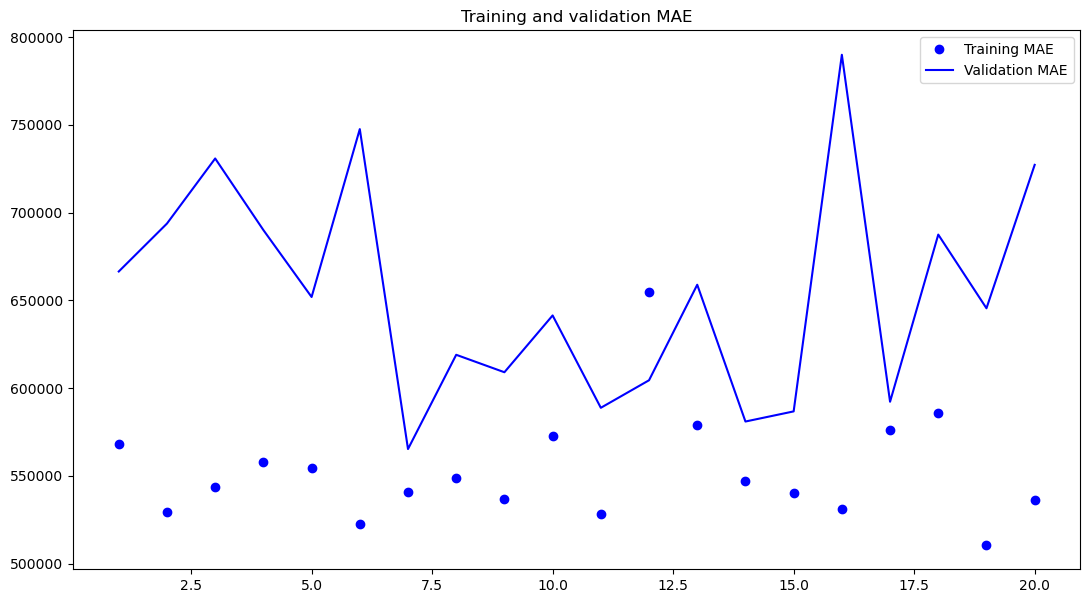

In [1242]:
plot_training_performance([[144833377206272.0, 72339395969024.0, 111695246655488.0, 137795167322112.0, 98683626455040.0, 87617819377664.0, 122688710377472.0, 99439993683968.0, 93992456814592.0, 146993326325760.0, 121144560582656.0, 384510201954304.0, 160484942675968.0, 145392746364928.0, 139525057675264.0, 89118784618496.0, 214676289880064.0, 202895496577024.0, 98259196444672.0, 118169725304832.0], [568261.75, 529492.5625, 543932.4375, 557956.6875, 554405.6875, 522717.5625, 540601.5625, 548613.0, 537034.5625, 572478.25, 528440.5, 654966.875, 578879.6875, 547304.0625, 540026.0625, 531033.4375, 575921.1875, 585992.4375, 510735.2812, 536002.9375], [1530400597868544.0, 1530385028612096.0, 1530353084792832.0, 1530362211598336.0, 1530434957606912.0, 1530343957987328.0, 1530464351289344.0, 1530418985697280.0, 1530449453121536.0, 1530386102353920.0, 1530464619724800.0, 1530394826506240.0, 1530435628695552.0, 1530426501890048.0, 1530466767208448.0, 1530395363377152.0, 1530424220188672.0, 1530420596310016.0, 1530429320462336.0, 1530342615810048.0], [666458.9375, 693780.5, 730847.5625, 690074.9375, 651924.25, 747590.8125, 565287.3125, 618991.6875, 609051.1875, 641412.0, 588784.8125, 604478.4375, 658911.0625, 580968.25, 586739.0, 789944.125, 592235.9375, 687483.125, 645495.875, 727221.0625]])


In [514]:
G_10_5_5_loaded = keras.models.load_model("G_10_5_5.keras")
G_10_5_5_loaded.evaluate(G_10_5_5_X_test, G_10_5_5_y_test)

2147/2147 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 5515585190363136.0000 - mae: 831583.1875


[4432447588532224.0, 781087.375]

Test Performance of the Model:

In [515]:
print(f"Log Loss: {log_loss(G_10_5_5_loaded, G_10_5_5_X_test, G_10_5_5_y_test)}")

print(f"Prediction: {predicted_m_height(G_10_5_5_loaded, G_10_5_5_X_test)}")

2147/2147 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step
Log Loss: 9.626847393960182
2147/2147 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step
Prediction: [341213.3  247683.22 256043.06 ... 507016.44 310698.78 276733.75]


#### Case 19: n = 10, k = 6, m = 2

In [517]:
G_10_6_2 = data[(data.n.isin([10])) & (data.k.isin([6])) & (data.m == 2)].reset_index().iloc[:,1:]

G_10_6_2

,n,k,m,result,P
0,10,6,2,386.739228,"[-46.15043695524083, -77.24328205975218, 50.49..."
1,10,6,2,234.878569,"[42.73092482261896, 71.98202590408744, 15.7698..."
2,10,6,2,450.843372,"[-61.321048786971204, 9.44627633009219, -66.48..."
3,10,6,2,511.276372,"[77.23760709275604, 91.0266705429629, 61.18568..."
4,10,6,2,438.960047,"[82.74747810106464, -34.12647123814631, -33.56..."
...,...,...,...,...,...
610025,10,6,2,817.318160,"[79.772171036294, -59.37072825834495, -91.9641..."
610026,10,6,2,506.237863,"[32.84640987210892, -96.58741534477798, -82.61..."
610027,10,6,2,381.768188,"[98.27864527598885, -48.44530268450919, 59.281..."
610028,10,6,2,421.348048,"[74.70556776619199, 85.83521702119327, 99.9399..."


In [518]:
G_10_6_2_X_train, G_10_6_2_y_train, G_10_6_2_X_val, G_10_6_2_y_val, G_10_6_2_X_test, G_10_6_2_y_test = convert_df_to_tf_input(G_10_6_2)

Dimensions of Input: (610030, 27)
Dimensions of Output: (610030,)


In [522]:
G_10_6_2_model = model()
G_10_6_2_model.compile(optimizer = 'rmsprop',
                  loss = 'mse',
                  metrics = ['mae'])
    
G_10_6_2_callbacks = [
                    keras.callbacks.ModelCheckpoint("G_10_6_2.keras",
                                        save_best_only=True),
                    ]
G_10_6_2_model.summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_120 (Dense)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_121 (Dense)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_122 (Dense)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_123 (Dense)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_124 (Dense)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_125 (Dense)               │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [523]:
G_10_6_2_model.fit(G_10_6_2_X_train,
                  G_10_6_2_y_train,
                  validation_data = (G_10_6_2_X_val, G_10_6_2_y_val),
                  callbacks=G_10_6_2_callbacks,
                  batch_size = 256,
                  epochs = 20)

Epoch 1/20
1669/1669 ━━━━━━━━━━━━━━━━━━━━ 80s 46ms/step - loss: 84636.3438 - mae: 153.5222 - val_loss: 55799.6758 - val_mae: 122.9764
Epoch 2/20
1669/1669 ━━━━━━━━━━━━━━━━━━━━ 78s 46ms/step - loss: 70710.5391 - mae: 132.0817 - val_loss: 54385.1289 - val_mae: 121.4136
Epoch 3/20
1669/1669 ━━━━━━━━━━━━━━━━━━━━ 77s 46ms/step - loss: 95328.7500 - mae: 131.7290 - val_loss: 56975.6680 - val_mae: 159.0514
Epoch 4/20
1669/1669 ━━━━━━━━━━━━━━━━━━━━ 74s 44ms/step - loss: 60626.0391 - mae: 129.9799 - val_loss: 63178.3906 - val_mae: 132.0555
Epoch 5/20
1669/1669 ━━━━━━━━━━━━━━━━━━━━ 78s 47ms/step - loss: 54942.5977 - mae: 128.6412 - val_loss: 52742.2383 - val_mae: 124.7399
Epoch 6/20
1669/1669 ━━━━━━━━━━━━━━━━━━━━ 78s 47ms/step - loss: 76774.1406 - mae: 129.3863 - val_loss: 53345.1367 - val_mae: 119.4539
Epoch 7/20
1669/1669 ━━━━━━━━━━━━━━━━━━━━ 78s 47ms/step - loss: 67788.1016 - mae: 128.8554 - val_loss: 59450.1406 - val_mae: 174.2223
Epoch 8/20
1669/1669 ━━━━━━━━━━━━━━━━━━━━ 77s 46ms/step - loss

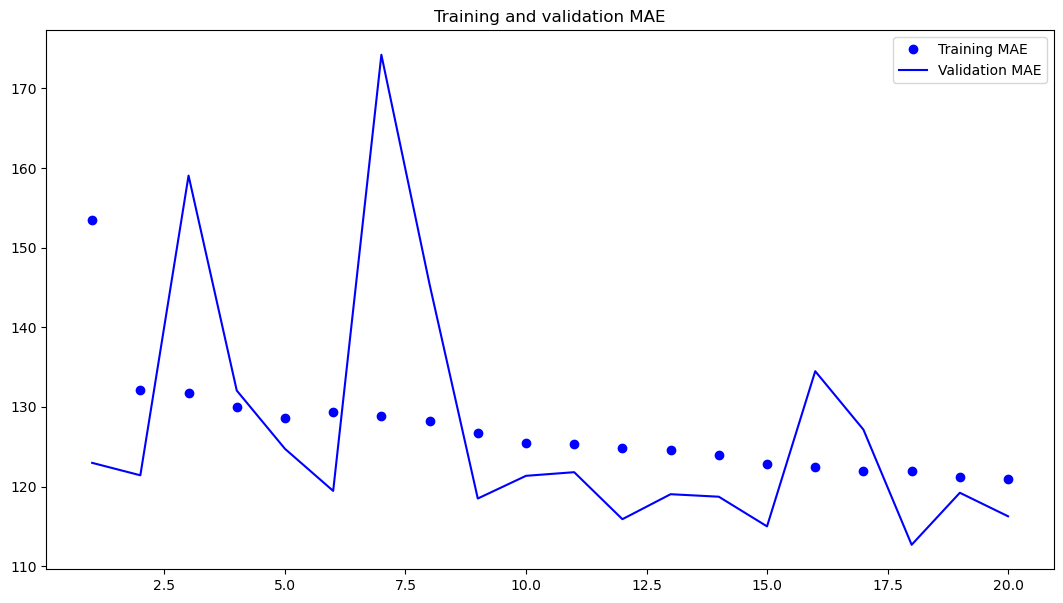

In [1246]:
plot_training_performance([[84636.3438, 70710.5391, 95328.75, 60626.0391, 54942.5977, 76774.1406, 67788.1016, 72679.4922, 58459.4062, 61398.4336, 57782.7812, 58794.6719, 54178.1016, 83820.3828, 53640.5469, 69624.3828, 55956.5273, 93943.9844, 80721.1953, 60193.6992], [153.5222, 132.0817, 131.729, 129.9799, 128.6412, 129.3863, 128.8554, 128.2199, 126.7196, 125.4742, 125.3089, 124.8652, 124.5577, 123.9593, 122.8045, 122.4237, 122.0079, 121.993, 121.2134, 120.9754], [55799.6758, 54385.1289, 56975.668, 63178.3906, 52742.2383, 53345.1367, 59450.1406, 52881.0117, 51737.0, 50609.1719, 49938.2578, 55639.0859, 56626.9414, 49447.1211, 52290.3594, 49882.2266, 49165.8086, 50156.332, 49024.2188, 49175.2812], [122.9764, 121.4136, 159.0514, 132.0555, 124.7399, 119.4539, 174.2223, 145.3873, 118.4964, 121.347, 121.8031, 115.9005, 119.0386, 118.7234, 115.0, 134.4847, 127.1491, 112.6877, 119.2194, 116.2665]]

                         )

In [524]:
G_10_6_2_loaded = keras.models.load_model("G_10_6_2.keras")
G_10_6_2_loaded.evaluate(G_10_6_2_X_test, G_10_6_2_y_test)

2860/2860 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 57081.8672 - mae: 119.4316


[54932.0859375, 118.89655303955078]

Test Performance of the Model:

In [525]:
print(f"Log Loss: {log_loss(G_10_6_2_loaded, G_10_6_2_X_test, G_10_6_2_y_test)}")

print(f"Prediction: {predicted_m_height(G_10_6_2_loaded, G_10_6_2_X_test)}")

2860/2860 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step
Log Loss: 0.21627003807173123
2860/2860 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step
Prediction: [480.39075 216.52513 366.9627  ... 537.1045  467.30615 416.51752]


#### Case 20: n = 10, k = 6, m = 3

In [527]:
G_10_6_3 = data[(data.n.isin([10])) & (data.k.isin([6])) & (data.m == 3)].reset_index().iloc[:,1:]

G_10_6_3

,n,k,m,result,P
0,10,6,3,1688.512168,"[-37.05972593828094, -49.525294534532904, -73...."
1,10,6,3,3122.111202,"[19.769921885197533, 78.24997179220802, 33.106..."
2,10,6,3,1603.389927,"[-45.26237100036935, -98.51597838177767, -24.7..."
3,10,6,3,1298.052019,"[-45.01114880071113, 78.0390319666003, -70.085..."
4,10,6,3,998.460122,"[-33.14209355323976, -27.56119114946219, 52.62..."
...,...,...,...,...,...
610161,10,6,3,33575.543455,"[0.005550558315945864, -0.501582929852745, -90..."
610162,10,6,3,837.538000,"[93.58286357679822, -98.20920425040221, 11.221..."
610163,10,6,3,664.950169,"[-79.60192633658855, -90.38414898618326, -70.2..."
610164,10,6,3,888.080800,"[-89.80227608643999, -83.973496339827, -96.418..."


In [528]:
G_10_6_3_X_train, G_10_6_3_y_train, G_10_6_3_X_val, G_10_6_3_y_val, G_10_6_3_X_test, G_10_6_3_y_test = convert_df_to_tf_input(G_10_6_3)

Dimensions of Input: (610166, 27)
Dimensions of Output: (610166,)


In [532]:
G_10_6_3_model = model()
G_10_6_3_model.compile(optimizer = 'rmsprop',
                  loss = 'mse',
                  metrics = ['mae'])
    
G_10_6_3_callbacks = [
                    keras.callbacks.ModelCheckpoint("G_10_6_3.keras",
                                        save_best_only=True),
                    ]
G_10_6_3_model.summary()

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_126 (Dense)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_127 (Dense)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_129 (Dense)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_130 (Dense)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_131 (Dense)               │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [533]:
G_10_6_3_model.fit(G_10_6_3_X_train,
                  G_10_6_3_y_train,
                  validation_data = (G_10_6_3_X_val, G_10_6_3_y_val),
                  callbacks=G_10_6_3_callbacks,
                  batch_size = 256,
                  epochs = 20)

Epoch 1/20
1669/1669 ━━━━━━━━━━━━━━━━━━━━ 82s 47ms/step - loss: 32286220.0000 - mae: 1482.1906 - val_loss: 14207227.0000 - val_mae: 1322.4772
Epoch 2/20
1669/1669 ━━━━━━━━━━━━━━━━━━━━ 77s 46ms/step - loss: 22755494.0000 - mae: 1421.6946 - val_loss: 14152285.0000 - val_mae: 1449.3656
Epoch 3/20
1669/1669 ━━━━━━━━━━━━━━━━━━━━ 77s 46ms/step - loss: 19629530.0000 - mae: 1412.4506 - val_loss: 14167470.0000 - val_mae: 1342.3678
Epoch 4/20
1669/1669 ━━━━━━━━━━━━━━━━━━━━ 77s 46ms/step - loss: 18803824.0000 - mae: 1400.3026 - val_loss: 14132838.0000 - val_mae: 1397.2667
Epoch 5/20
1669/1669 ━━━━━━━━━━━━━━━━━━━━ 77s 46ms/step - loss: 20086972.0000 - mae: 1416.9253 - val_loss: 14155007.0000 - val_mae: 1355.5837
Epoch 6/20
1669/1669 ━━━━━━━━━━━━━━━━━━━━ 77s 46ms/step - loss: 19159338.0000 - mae: 1416.7369 - val_loss: 14154308.0000 - val_mae: 1366.0023
Epoch 7/20
1669/1669 ━━━━━━━━━━━━━━━━━━━━ 77s 46ms/step - loss: 18129172.0000 - mae: 1416.8588 - val_loss: 14154007.0000 - val_mae: 1367.8302
Epoch 

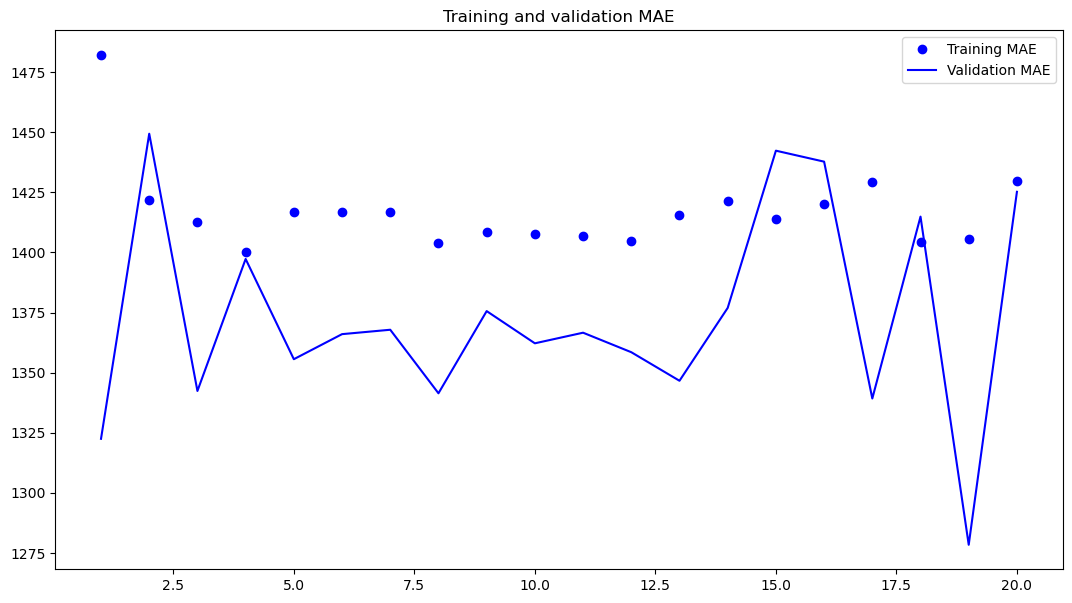

In [1250]:
plot_training_performance([[32286220.0, 22755494.0, 19629530.0, 18803824.0, 20086972.0, 19159338.0, 18129172.0, 19395656.0, 18348942.0, 17634540.0, 19376942.0, 15609891.0, 14941814.0, 15766487.0, 17983326.0, 21524502.0, 22300018.0, 15454188.0, 19733724.0, 20618996.0], [1482.1906, 1421.6946, 1412.4506, 1400.3026, 1416.9253, 1416.7369, 1416.8588, 1404.0358, 1408.4941, 1407.5736, 1407.0054, 1404.8026, 1415.6979, 1421.1697, 1414.0521, 1420.0643, 1429.3459, 1404.2662, 1405.7129, 1429.8719], [14207227.0, 14152285.0, 14167470.0, 14132838.0, 14155007.0, 14154308.0, 14154007.0, 14179007.0, 14175012.0, 14174607.0, 14183627.0, 14188390.0, 14192307.0, 14193030.0, 14197056.0, 14194301.0, 14220216.0, 14193066.0, 14329590.0, 14175944.0], [1322.4772, 1449.3656, 1342.3678, 1397.2667, 1355.5837, 1366.0023, 1367.8302, 1341.4052, 1375.5862, 1362.1899, 1366.6031, 1358.489, 1346.613, 1376.9109, 1442.3046, 1437.7419, 1339.2356, 1414.8828, 1278.4004, 1425.1959]]

                         )

In [534]:
G_10_6_3_loaded = keras.models.load_model("G_10_6_3.keras")
G_10_6_3_loaded.evaluate(G_10_6_3_X_test, G_10_6_3_y_test)

2861/2861 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 10454469.0000 - mae: 1373.3483


[12135109.0, 1391.6190185546875]

Test Performance of the Model:

In [535]:
print(f"Log Loss: {log_loss(G_10_6_3_loaded, G_10_6_3_X_test, G_10_6_3_y_test)}")

print(f"Prediction: {predicted_m_height(G_10_6_3_loaded, G_10_6_3_X_test)}")

2861/2861 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step
Log Loss: 1.0449660509645056
2861/2861 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step
Prediction: [2090.5535 2261.3057 2143.2046 ... 2108.3145 2299.4082 2115.9448]


#### Case 21: n = 10, k = 6, m = 4

In [536]:
G_10_6_4 = data[(data.n.isin([10])) & (data.k.isin([6])) & (data.m == 4)].reset_index().iloc[:,1:]

G_10_6_4

,n,k,m,result,P
0,10,6,4,16802.864235,"[-81.49775662810725, -7.6575088017866335, 98.5..."
1,10,6,4,63709.695569,"[-79.17563227699725, 57.47224398984798, 18.261..."
2,10,6,4,72410.539445,"[-92.44070253390242, 86.37360183420097, 89.496..."
3,10,6,4,40307.918252,"[67.78674564640576, 50.15771667480149, -36.726..."
4,10,6,4,32945.175993,"[6.877881235858155, 62.37212836948805, -30.680..."
...,...,...,...,...,...
608757,10,6,4,6607.763424,"[-21.783349620622715, 44.56953391702601, 16.22..."
608758,10,6,4,73701.193231,"[27.57991800476256, 94.708142818927, 24.820930..."
608759,10,6,4,12338.127189,"[88.44136985567249, -64.49851740599809, -30.22..."
608760,10,6,4,59535.795528,"[1.8290975831738194, 50.79535342302049, -1.641..."


In [537]:
G_10_6_4_X_train, G_10_6_4_y_train, G_10_6_4_X_val, G_10_6_4_y_val, G_10_6_4_X_test, G_10_6_4_y_test = convert_df_to_tf_input(G_10_6_4)

Dimensions of Input: (608762, 27)
Dimensions of Output: (608762,)


In [541]:
G_10_6_4_model = model()
G_10_6_4_model.compile(optimizer = 'rmsprop',
                  loss = 'mse',
                  metrics = ['mae'])
    
G_10_6_4_callbacks = [
                    keras.callbacks.ModelCheckpoint("G_10_6_4.keras",
                                        save_best_only=True),
                    ]
G_10_6_4_model.summary()

Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_132 (Dense)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_133 (Dense)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_134 (Dense)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_135 (Dense)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_136 (Dense)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_137 (Dense)               │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [542]:
G_10_6_4_model.fit(G_10_6_4_X_train,
                  G_10_6_4_y_train,
                  validation_data = (G_10_6_4_X_val, G_10_6_4_y_val),
                  callbacks=G_10_6_4_callbacks,
                  batch_size = 256,
                  epochs = 20)

Epoch 1/20
1665/1665 ━━━━━━━━━━━━━━━━━━━━ 80s 47ms/step - loss: 134016535625728.0000 - mae: 509812.2188 - val_loss: 126056107343872.0000 - val_mae: 573442.4375
Epoch 2/20
1665/1665 ━━━━━━━━━━━━━━━━━━━━ 77s 46ms/step - loss: 168085810053120.0000 - mae: 554038.8125 - val_loss: 126063833251840.0000 - val_mae: 545183.1250
Epoch 3/20
1665/1665 ━━━━━━━━━━━━━━━━━━━━ 77s 46ms/step - loss: 195475269484544.0000 - mae: 592149.3125 - val_loss: 126060091932672.0000 - val_mae: 488812.2500
Epoch 4/20
1665/1665 ━━━━━━━━━━━━━━━━━━━━ 77s 46ms/step - loss: 204392108130304.0000 - mae: 559385.2500 - val_loss: 126050998681600.0000 - val_mae: 542550.3125
Epoch 5/20
1665/1665 ━━━━━━━━━━━━━━━━━━━━ 77s 46ms/step - loss: 159773924261888.0000 - mae: 517631.1562 - val_loss: 126069462007808.0000 - val_mae: 668100.5000
Epoch 6/20
1665/1665 ━━━━━━━━━━━━━━━━━━━━ 77s 46ms/step - loss: 352676776771584.0000 - mae: 607266.9375 - val_loss: 126085031264256.0000 - val_mae: 735871.6250
Epoch 7/20
1665/1665 ━━━━━━━━━━━━━━━━━━━

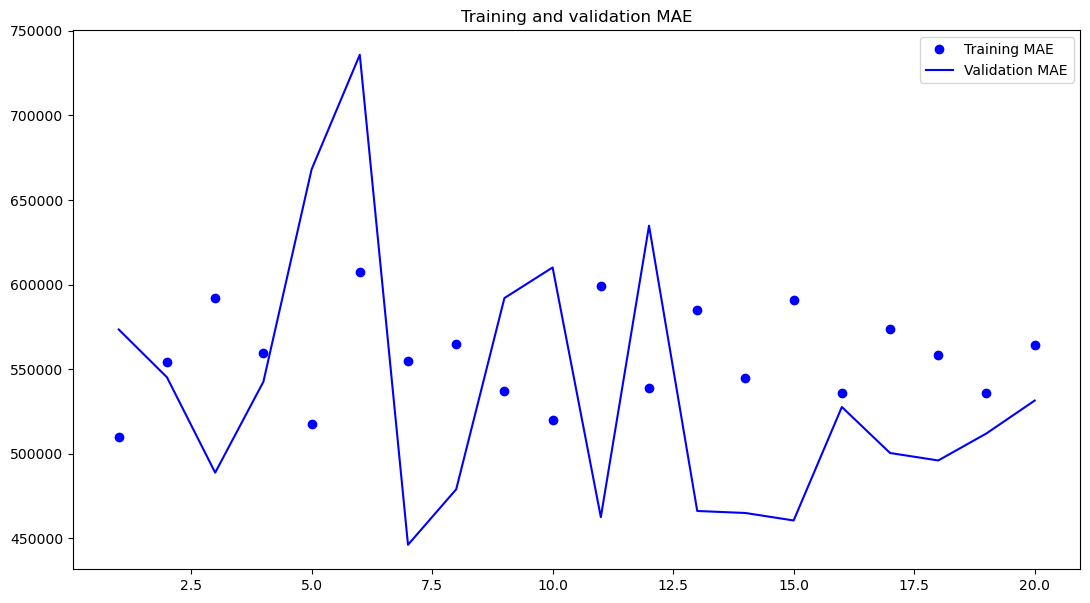

In [1254]:
plot_training_performance([[134016535625728.0, 168085810053120.0, 195475269484544.0, 204392108130304.0, 159773924261888.0, 352676776771584.0, 193888211959808.0, 221628365537280.0, 144643761111040.0, 120618460643328.0, 325960939339776.0, 162802983501824.0, 274160345415680.0, 141469679616000.0, 305876900511744.0, 141008171958272.0, 270187165122560.0, 166384919117824.0, 158994270257152.0, 204100956323840.0], [509812.2188, 554038.8125, 592149.3125, 559385.25, 517631.1562, 607266.9375, 554863.6875, 565063.6875, 536802.5, 520071.125, 599165.25, 539123.0625, 584832.25, 544690.9375, 590799.9375, 536041.75, 574038.5, 558261.5, 535932.25, 564111.25], [126056107343872.0, 126063833251840.0, 126060091932672.0, 126050998681600.0, 126069462007808.0, 126085031264256.0, 126083269656576.0, 126070577692672.0, 126059345346560.0, 126076021899264.0, 126074495172608.0, 126064605003776.0, 126061509607424.0, 126079335399424.0, 126068505706496.0, 126050092711936.0, 126066685378560.0, 126062583349248.0, 126070250536960.0, 126056879095808.0], [573442.4375, 545183.125, 488812.25, 542550.3125, 668100.5, 735871.625, 446170.4688, 478984.5312, 592027.8125, 610137.1875, 462506.4062, 634825.3125, 466152.375, 464961.2188, 460540.0, 527632.875, 500434.6875, 496021.2812, 512014.4062, 531447.125]]
                         )

In [543]:
G_10_6_4_loaded = keras.models.load_model("G_10_6_4.keras")
G_10_6_4_loaded.evaluate(G_10_6_4_X_test, G_10_6_4_y_test)

2854/2854 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 249796522672128.0000 - mae: 592918.9375


[183568764502016.0, 554096.125]

Test Performance of the Model:

In [544]:
print(f"Log Loss: {log_loss(G_10_6_4_loaded, G_10_6_4_X_test, G_10_6_4_y_test)}")

print(f"Prediction: {predicted_m_height(G_10_6_4_loaded, G_10_6_4_X_test)}")

2854/2854 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step
Log Loss: 8.564626652684455
2854/2854 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step
Prediction: [381639.84 294546.9  228937.31 ... 416492.72 384576.   488330.97]


#### Test Performance:

In [1292]:
test_performance = []
for n in [9,10]:
    for k in [4, 5, 6]:
        for m in range(2, n-k+1):
            test_performance.append({
                                     '0': f"G_{n}_{k}_{m}",
                                    'Log_Loss': eval(f"log_loss(G_{n}_{k}_{m}_loaded, G_{n}_{k}_{m}_X_test, G_{n}_{k}_{m}_y_test)"),
                                    'no_of_samples': len(eval(f"G_{n}_{k}_{m}_X_test"))
                                     })
test_performance = pd.DataFrame(test_performance)
test_performance.index = test_performance.iloc[:,0]
test_performance = test_performance.iloc[:,1:]
test_performance
test_performance

2143/2143 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step
2150/2150 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step
2139/2139 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step
2151/2151 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step
2863/2863 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step
2859/2859 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step
2859/2859 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step
4290/4290 ━━━━━━━━━━━━━━━━━━━━ 28s 7ms/step
4288/4288 ━━━━━━━━━━━━━━━━━━━━ 30s 7ms/step
1711/1711 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step
1717/1717 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step
1720/1720 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step
1716/1716 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step
1710/1710 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step
2149/2149 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step
2152/2152 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step
2144/2144 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step
2147/2147 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step
2860/2860 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step
2861/2861 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step
2854/2854 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step


,Log_Loss,no_of_samples
0,,
G_9_4_2,0.126815,68557
G_9_4_3,0.236053,68796
G_9_4_4,1.074123,68424
G_9_4_5,7.830406,68812
G_9_5_2,0.220841,91590
G_9_5_3,0.996560,91470
G_9_5_4,9.035178,91457
G_9_6_2,0.554307,137268
G_9_6_3,9.606955,137187


Total Test Log Loss:

In [1610]:
print(f"Test Log Loss: {np.dot(test_performance.Log_Loss, test_performance.no_of_samples)/test_performance.no_of_samples.sum()}")

Test Log Loss: 3.139631147051791


#### Code that needs to be executed:

__Please run all the cells from here onwards.__

The 'DNN_for_m_height' function takes the following inputs:
- n (int)
- k (int)
- m (int) 
- p_list (list of 2D numpy arrays)

and returns

- a list of scalars (m height values) for each matrix in p_list

In [ ]:
!pip install numpy
!pip install tensorflow
!pip install tamu_csce_636_project1

In [1616]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from keras import layers


def DNN_for_m_height(n, k, m, p_list):  
    
    """
    Parameters:
        n (int)
        k (int)
        m (int)
        p_list (list): a list of P matrices, each matrix will be a numpy array

    Returns:
        a list of scalars, e.g. the m-height value, one for each matrix
    """
    
    n, k, m = int(n), int(k), int(m)
    
    X = [[n] + [k] + [m] + p.flatten().tolist() for p in p_list]
    X = np.array(X)

    model = keras.models.load_model(f"G_{n}_{k}_{m}.keras")
    
    prediction = model.predict(X).flatten()
    
    __ = np.where(prediction < 1)[0]
    for i in range(len(prediction)):
        if i in __:
            prediction[i] = 1
            
    return prediction.tolist()

In [ ]:
"""
Enter the test dataset here 
σ = evaluator.eval(
    inputs=inputs,
    outputs=outputs,
    func=DNN_for_m_height,
)
"""